# MINFin in Python

This notebook implements *MinFin*, an analytical model developed to identify energy sector financing gaps for climate transitions in low- and middle-income countries (LMICs). MinFin quantifies investment needs, estimates financing costs, and evaluates anticipated sectoral cashflows to highlight financial shortfalls and explore feasible strategies to bridge them. The model’s primary goal is to facilitate better collaboration between energy and finance ministries, ensuring that energy planning aligns with national financial capacities and macroeconomic considerations. This python version is based on the original Excel version of MinFin, which can be found [here](https://zenodo.org/records/14844158).

## Reading the input data

- We can read the input data from the Excel file using the `pandas` library. The excel sheet we use is the Excel version of MinFin.
- A sample data set is provided in the `data` folder.

In [5]:
# Commented out the below line for installation of pandas if it is already installed
# !python3 -m pip install pandas

import pandas as pd

# Define file path
# file_path = "C:\\Users\\Zixuan\\Downloads\\MinFin V1.0.0kc.xlsm"
file_path = "MinFin V1.0.0kc.xlsm"
# Load the Excel file and check available sheet names
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
# Display sheet names
sheet_names


['Definitions',
 'Visualisation Dashboard',
 'Financial Instruments',
 'High Level Dashboard',
 'Financing Baseline',
 'Funding Baseline',
 'Investment Needs',
 'OSeMOSYS (Input)',
 'FFRM (Input)']

In [6]:
import sys
sys.modules.pop("MinFin", None)  # clean the cache of MinFin module, in case it is changed between runs.
from MinFin import load_excel_data
    
df_param_constraints, df_financing_baseline, df_funding_baseline, df_scenarios, df_currencies, df_technologies =  load_excel_data(file_path)

df_technologies.head(5) # show the first 5 rows of the technologies sheet

,Name,Description,Classification
0,PWRBIO001,Biomass power plant,Biomass
1,PWRCOA001,Coal power plant,Coal
2,PWRGEO,Geothermal power plant,Geothermal
3,PWROHC001,Light fuel oil power plant,Oil
4,PWROHC002,Oil fired gas turbine - SCGT,Oil


In [8]:
class BaseDefinition:
    def __init__(self, name: str, description: str):
        self.name = name
        self.description = description
    
    def __repr__(self):
        return f"{self.__class__.__name__}(name='{self.name}', description='{self.description}')"

class ParameterConstraint(BaseDefinition):
    pass

class FinancingBaseline(BaseDefinition):
    pass

class FundingBaseline(BaseDefinition):
    pass

class Scenario(BaseDefinition):
    pass

class Currency:
    def __init__(self, code: str, currency: str):
        self.code = code
        self.currency = currency
    
    def __repr__(self):
        return f"Currency(code='{self.code}', currency='{self.currency}')"

class Technology:
    def __init__(self, name: str, description: str, classification: str):
        self.name = name
        self.description = description
        self.classification = classification
    
    def __repr__(self):
        return f"Technology(name='{self.name}', description='{self.description}', classification='{self.classification}')"

# Creating a list of objects from extracted data
def load_definitions_from_dataframe(df, cls):
    return [cls(row["Name"], row["Description"]) for _, row in df.iterrows()]

def load_currencies_from_dataframe(df):
    return [Currency(row["Code"], row["Currency"]) for _, row in df.iterrows()]

def load_technologies_from_dataframe(df):
    return [Technology(row["Name"], row["Description"], row["Classification"]) for _, row in df.iterrows()]

# Example usage:
constraints = load_definitions_from_dataframe(df_param_constraints, ParameterConstraint)
baselines = load_definitions_from_dataframe(df_financing_baseline, FinancingBaseline)
fundings = load_definitions_from_dataframe(df_funding_baseline, FundingBaseline)
scenarios = load_definitions_from_dataframe(df_scenarios, Scenario)
currencies = load_currencies_from_dataframe(df_currencies)
technologies = load_technologies_from_dataframe(df_technologies)
# for constraint in constraints:
#     print(constraint)
# for baseline in baselines:
#     print(baseline)
# for funding in fundings:
#     print(funding)
# for scenario in scenarios:
#     print(scenario)
# for currency in currencies:
#     print(currency)
# for technology in technologies:
#     print(technology)
# technologies


## FFRM Sheet

We load the FFRM sheet here, for the stranded cost of oil, gas, and coal.

In [10]:
pd.set_option('future.no_silent_downcasting', True)# This is to avoid the warning of downcasting the data types. No need to worry about it.

# Load the entire "OSeMOSYS (Input)" sheet once to avoid multiple reads
df_osemosys_full = pd.read_excel(file_path, sheet_name="OSeMOSYS (Input)")#, engine="openpyxl")
df_ffrm_full = pd.read_excel(file_path, sheet_name="FFRM (Input)")

In [11]:
def process_ffrm_input(df_ffrm_full):
    """
    Load FFRM Input data for Oil, Gas, and Coal into a structured DataFrame.
    
    Parameters:
    df_ffrm_full (DataFrame): The full FFRM (Input) sheet from the Excel file.

    Returns:
    DataFrame: A merged DataFrame containing all energy types with multi-level column names.
    """
    starting_cols = {'Oil': 1, 'Gas': 4, 'Coal': 7}  # Define starting columns
    starting_row = 5
    dfs = []  # List to store data from each energy type

    for energy_type, starting_col in starting_cols.items():
        # Extract relevant section
        df = df_ffrm_full.iloc[starting_row:starting_row+48, starting_col:starting_col+2].copy()  # +3 to ensure all columns
        
        # Extract the column headers
        scenarios = df_ffrm_full.iloc[starting_row-1, starting_col:starting_col+2].dropna().tolist()
        
        # Check if we extracted the correct number of columns
        if len(scenarios) != df.shape[1]:
            print(f"Warning: Column count mismatch for {energy_type}. Expected {df.shape[1]}, got {len(scenarios)}.")
            print(f"Scenarios found: {scenarios}")

        # Define column names with MultiIndex format (EnergyType, Scenario)
        df.columns = pd.MultiIndex.from_product([[energy_type], scenarios[:df.shape[1]]])  # Ensure header length matches

        # Insert Year column
        df.insert(0, ("General", "Year"), df_ffrm_full.iloc[starting_row:starting_row+48, 0].values)

        # Fill missing values with 0
        df.iloc[:, 1:] = df.iloc[:, 1:].fillna(0)
        df.reset_index(drop=True, inplace=True)
        # Compute stranded cost and add it as a new column
        if len(scenarios) >= 2:
            df[(energy_type, "Stranded Cost")] = df[(energy_type, scenarios[1])] - df[(energy_type, scenarios[0])]

        # Append to list
        dfs.append(df)

    # Merge all energy types into a single DataFrame
    df_final = pd.concat(dfs, axis=1)

    # Remove duplicate Year columns (keep only one)
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]

    return df_final

# We process the raw FFRM sheet here, plus compute the stranded cost of oil, gas, and coal.
df_ffrm = process_ffrm_input(df_ffrm_full)

df_ffrm.head(5)


General     Oil                             Gas                          \
     Year NetZero LeastCost Stranded Cost NetZero LeastCost Stranded Cost   
0    2023       0         0             0       0         0             0   
1    2024       0         0             0       0         0             0   
2    2025       0         0             0       0         0             0   
3    2026       0         0             0       0         0             0   
4    2027       0         0             0       0         0             0   

     Coal                          
  NetZero LeastCost Stranded Cost  
0      34        56            22  
1      35        58            23  
2      36        60            24  
3      37        62            25  
4      38        64            26

# Exchange rate extraction: 
## Temporarily generated, maybe get from the sheet in the future 

In [172]:
import numpy as np
# Define the years from 2015 to 2079
years = np.arange(2000, 2080)

# Define some example currencies
currencies = ["EUR", "GBP", "JPY", "CNY", "INR", "AUD", "CAD"]

# Generate synthetic exchange rates with a simulated yearly change
np.random.seed(42)  # For reproducibility
base_rates = {
    'USD': 1#, "EUR": 1.1, "GBP": 1.3, "JPY": 110, "CNY": 6.5, "INR": 74, "AUD": 1.4, "CAD": 1.25
}
base_rates["KES"] = 1

# Simulate yearly fluctuations for KES (small changes)
fluctuations = np.cumsum(np.random.normal(0, 0.01, len(years)))  # Simulated yearly change
# Create a DataFrame to store the exchange rates
exchange_rates = pd.DataFrame({"Year": years})
exchange_rates["KES"] = base_rates["KES"]# * (1 + fluctuations)
# exchange_rates["USD"] = base_rates["USD"]
# Simulate yearly fluctuations in exchange rates
for currency, base_rate in base_rates.items():
    fluctuations = np.cumsum(np.random.normal(0, 0.01, len(years)))  # Simulated yearly change
    exchange_rates[currency] = base_rate #* (1 + fluctuations)
exchange_rates
melted = exchange_rates.melt(id_vars=["Year"], var_name="Currency", value_name="Exchange Rate")
melted.T


,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,159
Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2070,2071,2072,2073,2074,2075,2076,2077,2078,2079
Currency,KES,KES,KES,KES,KES,KES,KES,KES,KES,KES,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
Exchange Rate,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


# Funding Baseline Sheet

In [173]:
# Load the "Funding Baseline" sheet from the Excel file
# file_path = "/mnt/data/GitHub Master 250205.xlsm"
from MinFin import process_funding_baseline
# Read the full "Funding Baseline" sheet
df_funding_baseline_full = pd.read_excel(file_path, sheet_name="Funding Baseline", engine="openpyxl")
df_final = process_funding_baseline(df_funding_baseline_full,melted)
df_funding_baseline=process_funding_baseline(df_funding_baseline_full,melted)
df_funding_baseline.head()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



,Source,Name,Type,Year,Volume (Million),Currency,Govt Share,Volume (Foreign Currency USD),Exchange Rate,volume_in_usd
0,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2010,212.585322,USD,1,212.585322,1.0,212.585322
1,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2011,212.585322,USD,1,212.585322,1.0,212.585322
2,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2012,212.585322,USD,1,212.585322,1.0,212.585322
3,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2013,185.199015,USD,1,185.199015,1.0,185.199015
4,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2014,229.64721,USD,1,229.64721,1.0,229.64721


In [174]:
# Selecting relevant columns: "Budget", "Grant", "SOE Gen." along with "Year"
# Ensure "Type" column exists and contains relevant funding categories

# df_funding_develop.iloc[-2]

from MinFin import get_funding_envelope

df_funding_envelope=get_funding_envelope(df_funding_baseline)
df_funding_envelope

Type,Budget,Grant,SOE Gen.
Year,,,
2010,212.585322,8.15,136.589319
2011,212.585322,17.5,137.046688
2012,212.585322,0,136.393265
2013,185.199015,8.4,283.436368
2014,229.64721,0.95,212.107323
2015,288.241015,41.8,300.464361
2016,270.604363,2.477377,435.706102
2017,342.577463,0,268.491333
2018,231.607571,0,346.120479


In [175]:
# ffe_least_cost[0:5]

# OSeMOSYS Sheet

In [176]:
class data_extractor:
    def __init__(self,scenario) -> None:
        self.scenario = scenario
        self.starting_rows = {'net_zero': 137,'least_cost': 137}
        self.starting_cols = {'least_cost': {'variable_cost': 4, 'fixed_cost': 6, 'annual_elec_production': 10,'co2_emission':18}}
        self.starting_cols['net_zero']= { key:value-1 for key,value in self.starting_cols['least_cost'].items()}
        self.starting_cols[scenario]['carbon_price'] = 16
        
    def get_cols(self,name_of_cost,df_osemosys_full):
        starting_row = self.starting_rows[self.scenario]
        starting_col = self.starting_cols[self.scenario]
        if name_of_cost in ['year','years','y']:
            years = df_osemosys_full.iloc[starting_row:starting_row+46, 0:1]
            return years
        cost = df_osemosys_full.iloc[starting_row:starting_row+46, starting_col[name_of_cost]:starting_col[name_of_cost]+1]  # A10:AH66 in Million
        cost.reset_index(drop=True, inplace=True)
        return cost
    
    @staticmethod
    def load_osemosys_input(scenario,df_osemosys_full):
        starting_rows = {'net_zero': 9,'least_cost': 73}
        starting_row = starting_rows[scenario]
        # Extract different sections
        df_captial_cost = df_osemosys_full.iloc[starting_row:starting_row+56, 0:34]  # A10:AH66 in Million
        df_captial_cost.columns = ["Year"] + list(df_osemosys_full.iloc[starting_row-1, 1:34])  # Rename columns using the header row
        df_captial_cost.reset_index(drop=True, inplace=True)

        df_captial_cost.iloc[:, 1:] = df_captial_cost.iloc[:, 1:].fillna(0)  # Replace NaN with 0
        # Calculate the total row
        total_row = pd.DataFrame(df_captial_cost.iloc[:, 1:].sum()).T  # Sum all numerical columns and transpose
        total_row.insert(0, "Year", "Total")  # Set the "Year" column to "Total"

        # Append the total row to the DataFrame
        df_captial_cost =pd.concat([df_captial_cost,total_row], ignore_index=True)
        
        df_ffe  = df_osemosys_full.iloc[starting_row:starting_row+56, 35:39]  # A10:AH66 in Million
        df_ffe.columns =  list(df_osemosys_full.iloc[starting_row-1, 35:39])  # Rename columns using the header row
        df_ffe.reset_index(drop=True, inplace=True)
        
        df_ffe.iloc[:, 1:] = df_ffe.iloc[:, 1:].fillna(0)  # Replace NaN with 0

        df_ffe["Total"] = df_ffe.iloc[:, 0:].sum(axis=1)
        df_ffe["Year"] = df_captial_cost["Year"]

        # Calculate the total row
        total_row = pd.DataFrame(df_ffe.iloc[:, 1:].sum()).T  # Sum all numerical columns and transpose
        total_row.iloc[:,-1]= "Total" # Set the "Year" column to "Total"
        df_ffe =pd.concat([df_ffe,total_row], ignore_index=True)
        df_ffe.set_index("Year", inplace=True, drop=False)

        return df_captial_cost, df_ffe

  
    def get_totals(self,df_osemosys_full):
        #Load Variable Cost, Fixed Cose, and Annual Electricity
        # starting_cols = {'least_cost': {'variable_cost': 4, 'fixed_cost': 6, 'elec_production': 10,'co2_emission':18}}
        # starting_cols['net_zero']= { key:value-1 for key,value in starting_cols['least_cost'].items()}
       
        # print(starting_col.keys())
        # Extract different sections
        
        # print(years)
        totals=pd.DataFrame()
        for name in self.starting_cols[self.scenario].keys(): 
            
            totals[name] = self.get_cols(name,df_osemosys_full)

        years = self.get_cols('year',df_osemosys_full)
        totals.set_index(years.iloc[:,0], inplace=True)
        # print(years.iloc[0,0])
        totals['capital_cost'] = self.cal_total_capital(since_year=years.iloc[0,0])["total_capital"].values
        totals['total_cost'] = totals['capital_cost']+totals['variable_cost']+totals['fixed_cost']
        totals['cost_of_elec_in_pj'] = totals['total_cost']/totals['annual_elec_production']
        totals['cost_of_elec'] = totals['cost_of_elec_in_pj']/3.6 #Convert PJ/USD to TWh/USD
        totals['cost_of_co2'] = totals['co2_emission']*totals['carbon_price'] #Convert PJ/USD to TWh/USD
        # totals.reset_index(inplace=True)  # Moves the current index to a column
        totals.index.name = None  # Removes "MINFin" from the index name
        # df_ffe_least_cost.set_index("Year", inplace=True)
        return totals
    def cal_total_capital(self, since_year=2025):
        df_capatial_cost_detail ,df_ffe=self.load_osemosys_input(self.scenario,df_osemosys_full)
        # Convert 'Year' column to numeric (ignoring 'Total' row)
        df_capatial_cost_detail["Year"] = pd.to_numeric(df_capatial_cost_detail["Year"], errors='coerce')
        # df_ffe["Year"] = pd.to_numeric(df_ffe["Year"], errors='coerce')

        # Filter for rows where Year > 2025
        df_filtered = df_capatial_cost_detail[df_capatial_cost_detail["Year"] >= since_year]
        # df_ffe_filtered = df_ffe[df_ffe["Year"]>=since_year]
        # Sum across all columns (excluding 'Year')
        total_captital = df_filtered.iloc[:, 1:].sum(axis=1).to_frame()
        total_captital.columns=["total_capital"]
        # df_stacked = pd.concat([total_captital, df_ffe_filtered], axis=1)  # axis=0 → row-wise
        return total_captital
    
    # def load_fossil_fuel_ex(self):
    
        # print(total_captital.head())
# df_netzero ,df_ffe=load_osemosys_input('net_zero',df_osemosys_full)
# df_netzero[0:5]
# df_ffe[0:5] 
net_zero_extrator = data_extractor('net_zero')
net_zero_summary = net_zero_extrator.get_totals(df_osemosys_full)
full_cap_cost_net_zero, df_ffe_net_zero = data_extractor.load_osemosys_input('net_zero',df_osemosys_full)
# net_zero_summary
full_cap_cost_net_zero.head()
df_ffe_net_zero

,BIO,COA,OIL,GAS,Total,Year
Year,,,,,,
2015,0,0,0,0,0,2015
2016,0,0,0,0,0,2016
2017,0,0,0,0,0,2017
2018,0,0,0,0,0,2018
2019,0.1443,0,84.2176,0,84.3619,2019
2020,0.1443,0,96.1124,0,96.2567,2020
2021,0.1443,0,109.6509,0,109.7952,2021
2022,0.1443,0,42.3744,0,42.5187,2022
2023,0.2453,0,43.7724,0,44.0177,2023


In [177]:
least_cost_extrator = data_extractor('least_cost')
least_cost_summary =  least_cost_extrator.get_totals(df_osemosys_full)
full_cap_cost_least_cost, df_ffe_least_cost = data_extractor.load_osemosys_input('least_cost',df_osemosys_full)
least_cost_summary.head()

,variable_cost,fixed_cost,annual_elec_production,co2_emission,carbon_price,capital_cost,total_cost,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,139.3078,224.812,335.7138,0.4391,67.060662,569.3439,933.4637,2.780534,0.772371,29.446337
2026,83.7825,237.1475,349.8989,0.1041,68.569526,978.1743,1299.1043,3.712799,1.031333,7.138088
2027,100.4543,244.5441,367.5427,0.1522,70.112341,1085.6692,1430.6676,3.892521,1.081256,10.671098
2028,98.1232,262.9955,390.1257,0.1928,71.689869,954.408,1315.5267,3.372059,0.936683,13.821807
2029,74.1878,289.8432,421.2278,0.1626,73.302891,1637.2812,2001.3122,4.75114,1.319761,11.91905


In [178]:
co2_savings = pd.DataFrame()
co2_savings['co2_savings'] = least_cost_summary['cost_of_co2']-net_zero_summary['cost_of_co2']
co2_savings.head()

,co2_savings
2025,0.0
2026,0.0
2027,-3.225168
2028,-3.226044
2029,-2.624243


In [179]:
#2025 -2070 period total
cost_keys = ['capital_cost','variable_cost','fixed_cost']
data = []
for key in cost_keys:
    data.append({
        "Scenarios": key,  # Scenarios: net zero / least cost
        "NetZero": net_zero_summary[key].sum(),# Million USD
        "LeastCost": least_cost_summary[key].sum(),#Million USD
    })
# net_zero_summary['capital_cost']
period_total = pd.DataFrame(data).T
period_total.columns = period_total.iloc[0] 
period_total = period_total[1:]
period_total['total'] = period_total.iloc[0:,:].sum(axis=1)
period_total

Scenarios,capital_cost,variable_cost,fixed_cost,total
NetZero,131149.5675,5254.9279,42852.2537,179256.7491
LeastCost,129624.9373,6543.0711,42995.5927,179163.6011


In [180]:
five_year_intervals = list(range(2025, 2070, 5))  # Generates [2025, 2030, 2035, ..., 2065]
df_5yr_avg = pd.DataFrame({"Year": five_year_intervals})
# Compute 5-year averages for each interval
for key in cost_keys:
    df_5yr_avg[f"nz_{key}"] = net_zero_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"lc_{key}"] = least_cost_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"delta_{key}"] = df_5yr_avg[f"lc_{key}"] - df_5yr_avg[f"nz_{key}"]
    
df_5yr_avg["emission_saving"] = co2_savings["co2_savings"].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False).mean().reset_index(drop=True)    
df_5yr_avg         
         

,Year,nz_capital_cost,lc_capital_cost,delta_capital_cost,nz_variable_cost,lc_variable_cost,delta_variable_cost,nz_fixed_cost,lc_fixed_cost,delta_fixed_cost,emission_saving
0,2025,1081.1973,1044.97532,-36.22198,109.8241,99.17112,-10.65298,248.98792,251.86846,2.88054,-1.815091
1,2030,1261.28836,1271.49458,10.20622,79.13008,90.10292,10.97284,348.24074,343.6103,-4.63044,3.863266
2,2035,1665.83412,1719.46714,53.63302,75.38272,72.27926,-3.10346,462.64224,464.05672,1.41448,5.999035
3,2040,2474.19112,2463.69962,-10.4915,59.44428,68.75464,9.31036,670.69192,668.82898,-1.86294,10.109944
4,2045,3068.56706,3096.5954,28.02834,70.58874,84.25832,13.66958,896.94448,894.77544,-2.16904,21.50155
5,2050,3518.28656,3471.1731,-47.11346,91.29092,129.3102,38.01928,1115.34056,1102.9495,-12.39106,88.182874
6,2055,3275.16582,3271.50528,-3.66054,146.53176,184.32838,37.79662,1296.39404,1298.99336,2.59932,134.140801
7,2060,4107.44386,4034.1658,-73.27806,173.74396,237.8042,64.06024,1488.49464,1501.0932,12.59856,211.798231
8,2065,4716.97616,4624.6332,-92.34296,201.33938,280.67728,79.3379,1682.80878,1706.98438,24.1756,289.02662


In [181]:
# Read of FFRM input



In [182]:
'''
# Load the specific sheet "Financing Baseline" including formulas
df_financing_baseline = pd.read_excel(file_path, sheet_name="Financing Baseline", engine="openpyxl", keep_default_na=False)

# Extract formulas by reading as raw values (formulas are not evaluated, just extracted as strings if present)
import openpyxl

# Load workbook using openpyxl (preserves formulas)
wb = openpyxl.load_workbook(file_path, data_only=False)  # data_only=False keeps formulas instead of evaluated values

# Select the specific sheet
ws = wb["Financing Baseline"]

# Extract formulas
formulas = {}
for row in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
    for cell in row:
        if isinstance(cell.value, str) and cell.value.startswith("="):  # Check for Excel formulas
            formulas[cell.coordinate] = cell.value

# Display extracted formulas
formulas
'''


'\n# Load the specific sheet "Financing Baseline" including formulas\ndf_financing_baseline = pd.read_excel(file_path, sheet_name="Financing Baseline", engine="openpyxl", keep_default_na=False)\n\n# Extract formulas by reading as raw values (formulas are not evaluated, just extracted as strings if present)\nimport openpyxl\n\n# Load workbook using openpyxl (preserves formulas)\nwb = openpyxl.load_workbook(file_path, data_only=False)  # data_only=False keeps formulas instead of evaluated values\n\n# Select the specific sheet\nws = wb["Financing Baseline"]\n\n# Extract formulas\nformulas = {}\nfor row in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):\n    for cell in row:\n        if isinstance(cell.value, str) and cell.value.startswith("="):  # Check for Excel formulas\n            formulas[cell.coordinate] = cell.value\n\n# Display extracted formulas\nformulas\n'

# We now calculate the Investment Needs with input we have taken in

In [183]:
import pandas as pd
import numpy as np

global since_year 
since_year= 2025
def filter_data(data):
    data["Year"] = pd.to_numeric(data["Year"], errors='coerce')
    data = data[data["Year"]>=since_year]
    return data


def cal_invest_needs(least_cost_summary,net_zero_summary,df_ffe_least_cost,df_ffe_net_zero,df_ffrm):
    """Extracts and constructs the Investment Needs table from OSeMOSYS and FFRM sheets."""
    df_emission_savings = pd.DataFrame()
    df_emission_savings['emission_savings'] = least_cost_summary['co2_emission']-net_zero_summary['co2_emission']
    
    '''
    Savings on Fossil Fuel Expenditure
    '''
    fossil_fuel_savings = pd.DataFrame()
    
    fossil_fuel_savings = filter_data(df_ffe_least_cost)-filter_data(df_ffe_net_zero)
    fossil_fuel_no_earnings = fossil_fuel_savings.drop(columns=["Total", "Year"], errors="ignore").copy()  # Assuming df_funding_develop is the DataFrame

    fossil_fuel_no_earnings.iloc[:, :-1] = fossil_fuel_no_earnings.map(lambda x: max(x, 0))
    fossil_fuel_savings['Year'] = filter_data(df_ffe_least_cost)["Year"].astype(int)
    fossil_fuel_savings["expenditure"] = fossil_fuel_no_earnings.sum(axis=1)
    # for key in ["coal","oil","gas","biomass"]:
    #     fossil_fuel_savings[key] = 
    '''
    Financing Needs for FFR
    '''
    tech_list = ['Oil', 'Gas', 'Coal']

    df_financing_needs_ffr = df_ffrm.copy()
    for tech in tech_list:
        df_financing_needs_ffr.loc[:, (tech,tech)] = pd.DataFrame( df_ffrm[tech]['LeastCost'] - df_ffrm[tech]['NetZero'])
    
    # 用循环后求出 'Oil', 'Gas', 'Coal' 对应列的总和，并放到 ('Total','Total') 列中
    total_cols = [(tech, tech) for tech in tech_list]
    df_financing_needs_ffr.loc[:, ('Total', 'Total')] = df_financing_needs_ffr.loc[:, total_cols].sum(axis=1)

    '''
    Least Cost Financing needs
    '''
    
    # Calculate total financing needs for each technology category
    # Create a mapping of technology names to their categories
    tech_category_map = {tech.name: tech.classification for tech in technologies}

    #### LEAST COST:####
    # Create a new DataFrame to store the sum of costs per category for each year
    df_category_sum_lc = full_cap_cost_least_cost.copy()

    # Replace technology names with their corresponding categories
    df_category_sum_lc = df_category_sum_lc.rename(columns=tech_category_map)

    # Sum across the same category names (grouping columns with the same category)
    df_category_sum_lc = df_category_sum_lc.groupby(axis=1, level=0).sum()

    df_category_sum_lc  = filter_data(df_category_sum_lc)
    
    #### NET ZERO:####
    df_category_sum_nz = full_cap_cost_net_zero.copy()

    df_category_sum_nz = df_category_sum_nz.rename(columns=tech_category_map)

    df_category_sum_nz = df_category_sum_nz.groupby(axis=1, level=0).sum()

    df_category_sum_nz  = filter_data(df_category_sum_nz)
    

    return df_category_sum_lc,df_category_sum_nz,df_emission_savings,df_financing_needs_ffr.set_index(("General","Year"),drop=False),fossil_fuel_savings

# Example Usage
# file_path = "your_excel_file.xlsm"
# df_investment_needs = extract_investment_needs(file_path)
df_category_sum_lc,df_category_sum_nz,df_emission_savings,df_financing_needs_ffr,fossil_fuel_savings= cal_invest_needs(least_cost_summary,net_zero_summary,df_ffe_least_cost,df_ffe_net_zero,df_ffrm)
# df_emission_savings.head()
# full_cap_cost_least_cost
# df_ffrm
# least_cost_summary.keys()
# df_ffe_least_cost
df_category_sum_lc.index.name = None

'''
The following lines are for fitting a bug in MinFin 1.0.0
'''
categories_to_exclude = ['Offshore Wind', 'Onshore Wind']  # Replace with the categories you want to exclude
'''
##################################################################################################################
'''
df_category_sum_lc.set_index("Year",drop=True).drop(columns=categories_to_exclude).sum(axis=1).copy()
df_category_sum_nz.set_index("Year",drop=True).drop(columns=categories_to_exclude).sum(axis=1).copy()
incremental_investment = df_category_sum_nz - df_category_sum_lc
incremental_investment["Year"] = df_category_sum_lc["Year"]
incremental_investment_total = incremental_investment.set_index(df_category_sum_lc['Year']).drop(columns=categories_to_exclude+["Year"]).sum(axis=1)
df_category_sum_lc
# Assuming the data is stored in a pandas DataFrame called df_category_sum_lc
incremental_investment_total
# incremental_investment
# df_category_sum_nz

/var/folders/d3/x0jlm2j130q153pxwc3zts1h0000gp/T/ipykernel_53554/416389262.py:59: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/d3/x0jlm2j130q153pxwc3zts1h0000gp/T/ipykernel_53554/416389262.py:68: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Year
2025.0    300.0000
2026.0      0.0000
2027.0     32.4531
2028.0      0.0000
2029.0      0.0000
2030.0    -56.4066
2031.0   -164.8087
2032.0     23.3282
2033.0    -28.8673
2034.0   -105.6454
2035.0    -13.6561
2036.0    -34.2397
2037.0    -83.1552
2038.0    -70.8962
2039.0      0.0000
2040.0     86.0140
2041.0    -15.6333
2042.0    -27.1585
2043.0      0.0000
2044.0      0.0000
2045.0      0.0000
2046.0      0.0000
2047.0    -44.2841
2048.0   -202.6674
2049.0    -98.6975
2050.0    -83.9463
2051.0   -396.4780
2052.0     41.8084
2053.0    198.8494
2054.0    200.2610
2055.0    124.8831
2056.0    -59.2447
2057.0    122.1827
2058.0    -14.1929
2059.0     -2.4259
2060.0     53.7368
2061.0     29.6163
2062.0     61.1579
2063.0     92.9252
2064.0     93.8740
2065.0    206.4890
2066.0     37.9638
2067.0     28.7695
2068.0     72.3965
2069.0     83.3600
2070.0     97.0504
dtype: float64

In [184]:

# Define category mappings
def get_investment_needs_summary(df_category_sum):
    tech_categories = {
        "Renewable": ["Biomass", "Geothermal", "Solar PV", "CSP", "Hydropower", "Wind", "Nuclear"],
        "Fossil Fuel": ["Coal", "Gas", "Oil"],
        "Power Grid": ["Transmission", "Distribution"],
        "Other": ["Other","other"]
    }

    # Ensure technology names in DataFrame match category keys
    existing_cols = df_category_sum.columns.tolist()
    # Identify all existing columns (excluding "Year")
    # existing_cols = [col for col in df_aggregated.columns if col != "Year"]
    # Create a new DataFrame to store aggregated results
    df_summary = pd.DataFrame()
    df_summary["Year"] = df_category_sum["Year"]

    # Aggregate data for defined categories
    for category, techs in tech_categories.items():
        valid_techs = [tech for tech in techs if tech in existing_cols]  # Only use techs that exist in the DataFrame
        df_summary[category] = df_category_sum[valid_techs].sum(axis=1)

    # Compute total across all categories
    df_summary["Total"] = df_summary.iloc[:, 1:].sum(axis=1)
    return df_summary.set_index("Year",drop=False)
df_invest_need_summary_lc = get_investment_needs_summary(df_category_sum_lc)
df_invest_need_summary_lc.head()

,Year,Renewable,Fossil Fuel,Power Grid,Other,Total
Year,,,,,,
2025.0,2025.0,329.2926,191.7485,29.2420,0.0,550.2831
2026.0,2026.0,696.8164,168.7515,25.7349,0.0,891.3028
2027.0,2027.0,442.3225,368.9749,48.5603,0.0,859.8577
2028.0,2028.0,362.6366,368.1322,53.1132,0.0,783.8820
2029.0,2029.0,1184.0274,393.2781,59.9757,0.0,1637.2812


In [185]:
df_invest_need_summary_nz = get_investment_needs_summary(df_category_sum_nz)
df_invest_need_summary_nz.head()

,Year,Renewable,Fossil Fuel,Power Grid,Other,Total
Year,,,,,,
2025.0,2025.0,629.2926,191.7485,29.2420,0.0,850.2831
2026.0,2026.0,696.8164,168.7515,25.7349,0.0,891.3028
2027.0,2027.0,442.3225,401.4280,48.5603,0.0,892.3108
2028.0,2028.0,362.6366,368.1322,53.1132,0.0,783.8820
2029.0,2029.0,1184.0274,393.2781,59.9757,0.0,1637.2812


In [186]:
df_invest_need_summary = pd.concat(
    {
        "NetZero": df_invest_need_summary_nz,
        "LeastCost": df_invest_need_summary_lc,
        "Incremental": df_invest_need_summary_nz - df_invest_need_summary_lc
    },
    axis=1
)
df_invest_need_summary.loc[:,("Incremental","Year")] = df_invest_need_summary_nz["Year"]
df_invest_need_summary.loc[:,("FFRM","Total")] = df_financing_needs_ffr.loc[:,("Total","Total")]
df_invest_need_summary.loc[:, "Total financing"] = df_invest_need_summary.loc[:, ("FFRM", "Total")]+df_invest_need_summary.loc[:, ("NetZero", "Total")]
df_financing_needs_ffr
df_invest_need_summary
# df_financing_needs_ffr
df_category_sum_nz

,Battery,Biomass,CSP,Coal,Distribution,Gas,Geothermal,Hydropower,Nuclear,Offshore Wind,Oil,Onshore Wind,Solar PV,Transmission,Year
10,0,100.00,250,0,29.2420,0.0000,278.2473,1.0453,0.0000,0,191.7485,19.0608,0.0000,0,2025.0
11,0,25.00,0,0,25.7349,0.0000,544.2528,86.4096,0.0000,0,168.7515,86.8715,41.1540,0,2026.0
12,0,0.00,0,0,48.5603,83.0037,403.9956,38.3269,0.0000,0,318.4243,74.4683,0.0000,0,2027.0
13,0,20.00,0,0,53.1132,19.8531,331.8354,10.8012,0.0000,0,348.2791,170.5260,0.0000,0,2028.0
14,0,0.00,0,0,59.9757,0.0000,1158.2439,25.7835,0.0000,0,393.2781,0.0000,0.0000,0,2029.0
15,0,120.50,0,0,58.6536,58.2855,217.3667,127.5239,0.0000,0,384.6090,426.0647,0.0000,0,2030.0
16,0,50.00,0,0,56.0110,0.0000,529.4999,97.9077,0.0000,0,367.2810,0.0000,0.0000,0,2031.0
17,0,27.00,0,0,64.7620,0.0000,212.7511,63.4135,0.0000,0,424.6634,442.6991,0.0000,0,2032.0
18,0,7.50,0,0,62.9314,0.0000,163.4556,112.1932,0.0000,0,412.6597,596.6576,0.0000,0,2033.0
19,0,15.00,0,0,68.7988,0.0000,599.6646,87.4549,0.0000,0,451.1339,0.0000,0.0000,0,2034.0


## To translate finincial instruments


In [187]:
# net_zero_summary

### Grants


In [188]:
donor_discount_rate = 0.04
recipient_discount_rate = 0.0533
start_year = 2025
#We need Grant / Loan, Grant and loan
#Grant Element
# Define row and column names based on the extracted structure
rows = [
    # "Grants",
    # "Undiscounted",
    # "Donor",
    # "Recipient",
    # "Without FF Savings",
    # "Cumulative Grant Requirement",
    "Annual Grant Requirement",
    "New Power Generation",
    "Stranded Power Generation",
    "Variable Cost",
    "Fixed Cost"
]

columns =list(range(start_year, 2071))  # Years from 2025 to 2070
#  ["Total Over Modelling Period"] + 
df_ffe_least_cost["Year"] = pd.to_numeric(df_ffe_least_cost["Year"], errors="coerce")
df_ffe_net_zero["Year"] = pd.to_numeric(df_ffe_net_zero["Year"], errors="coerce")
df_ffe_net_zero = df_ffe_net_zero.dropna(subset=["Year"])  # Drop rows where Year is NaN
df_ffe_least_cost = df_ffe_least_cost.dropna(subset=["Year"])  # Drop rows where Year is NaN


# Create an empty DataFrame
df_grants_no_ffs = pd.DataFrame(index=rows, columns=columns)
df_grants_no_ffs.loc['Fixed Cost'] = net_zero_summary['fixed_cost']-least_cost_summary['fixed_cost']
df_grants_no_ffs.loc['Variable Cost'] =  (net_zero_summary['variable_cost']-least_cost_summary['variable_cost'])
fossil_fuel = (df_ffe_net_zero[df_ffe_net_zero.index >= start_year]['Total']-df_ffe_least_cost[df_ffe_least_cost.index.astype(float) >= start_year]["Total"])
variable_cost = net_zero_summary['variable_cost']-least_cost_summary['variable_cost']

df_grants_no_ffs.loc['Variable Cost'] = variable_cost - fossil_fuel #variable_cost.reset_index(drop=True,inplace=True)-fossil_fuel.reset_index(drop=True,inplace=True)
net_zero_summary

## Stranded Power Generation
stranded_cost = (df_ffrm["Oil"]['Stranded Cost']+df_ffrm["Gas"]['Stranded Cost']+df_ffrm["Coal"]['Stranded Cost']).to_frame().set_index(df_ffrm["General"]['Year'])
stranded_cost.index.name = None 
stranded_cost
df_grants_no_ffs.loc['Stranded Power Generation'] = stranded_cost.loc[stranded_cost.index >= start_year]["Stranded Cost"]
# incremental_investment_total.index.name = None
df_grants_no_ffs.loc['New Power Generation'] = incremental_investment_total
df_grants_no_ffs.loc['Annual Grant Requirement'] = df_grants_no_ffs.sum(axis=0)
df_grants_no_ffs.T
# df_grants
# df_grants
# net_zero_summary['variable_cost']-least_cost_summary['variable_cost']-df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]['Total']
# fossil_fuel
# variable_cost.iloc[-1] - fossil_fuel.iloc[-1]
# fossil_fuel
# df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]['Total']


,Annual Grant Requirement,New Power Generation,Stranded Power Generation,Variable Cost,Fixed Cost
2025,324.0,300.0,24,0.0,0.0
2026,25.0,0.0,25,0.0,0.0
2027,66.8221,32.4531,26,13.1888,-4.8198
2028,35.4931,0.0,27,13.294,-4.8009
2029,37.2837,0.0,28,14.0657,-4.782
2030,-34.3406,-56.4066,29,-10.4501,3.5161
2031,-137.113,-164.8087,30,-6.4782,4.1739
2032,51.2359,23.3282,31,-6.582,3.4897
2033,3.2342,-28.8673,32,-7.4456,7.5471
2034,-71.5694,-105.6454,33,-3.3494,4.4254


In [189]:
rows = ["Annual Grant Requirement Considering FF Savings", "Fossil Fuel Savings"]
df_grants_with_ffs = pd.DataFrame(index=rows, columns=columns)
df_grants_with_ffs.loc["Annual Grant Requirement Considering FF Savings"] = df_grants_no_ffs.loc["Annual Grant Requirement"]+fossil_fuel
df_grants_with_ffs.loc["Fossil Fuel Savings"] = -fossil_fuel
df_grants_with_ffs

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Annual Grant Requirement Considering FF Savings,324.0,25.0,71.4373,40.003,40.875,-36.97,-139.0689,48.7666,-6.4833,-75.3562,...,-39.4562,-14.9737,8.9739,3.5442,112.8668,-59.5691,-74.5359,-35.7643,-31.5862,-24.3048
Fossil Fuel Savings,-0.0,-0.0,-4.6152,-4.5099,-3.5913,2.6294,1.9559,2.4693,9.7175,3.7868,...,84.4713,93.6008,103.1902,111.2738,116.1024,121.4919,129.0093,135.4324,143.9882,152.5441


In [190]:
rows = ["Annual Grant Requirement Considering FF and Carbon Savings", "Carbon Savings"]
df_grants_with_ffs_carbon = pd.DataFrame(index=rows, columns=columns)
co2_savings = co2_savings.copy()
# df_grants_with_ffs_carbon.loc["Carbon Savings"] = 

# carbon_prices = [
#     67.06, 68.57, 70.11, 71.69, 73.30, 75.00, 76.69, 78.41, 80.18, 81.98,
#     83.83, 85.71, 87.64, 89.61, 91.63, 93.69, 95.80, 97.95, 100.16, 102.41,
#     104.72, 107.07, 109.48, 111.94, 114.46, 117.04, 119.67, 122.36, 125.12,
#     127.93, 130.81, 133.75, 136.76, 139.84, 142.99, 146.20, 149.49, 152.86,
#     156.30, 159.81, 163.41, 167.09, 170.85, 174.69, 178.62, 182.64
# ] # USD/ton CO2e
# carbon_prices = pd.DataFrame(carbon_prices, index=columns,columns=["carbon_prices"])

df_grants_with_ffs_carbon.loc["Carbon Savings", co2_savings.index] = co2_savings.values.flatten()
df_grants_with_ffs_carbon.loc["Annual Grant Requirement Considering FF and Carbon Savings"] = df_grants_with_ffs.loc["Annual Grant Requirement Considering FF Savings"] - df_grants_with_ffs_carbon.loc["Carbon Savings",:]


df_grants_with_ffs_carbon


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Annual Grant Requirement Considering FF and Carbon Savings,324.0,25.0,74.662468,43.229044,43.499243,-38.9275,-140.334244,47.174817,-18.54196,-77.799241,...,-232.796932,-225.779791,-221.001544,-242.984427,-144.715622,-329.747536,-362.632956,-339.986411,-356.639272,-370.972213
Carbon Savings,0.0,0.0,-3.225168,-3.226044,-2.624243,1.9575,1.265344,1.591783,12.05866,2.443041,...,193.340732,210.806091,229.975444,246.528627,257.582422,270.178436,288.097056,304.222111,325.053072,346.667413


In [191]:
def cal_donor_amount(donor_discount_rate,undiscounted_amounts):
    # print(undiscounted_amounts.reset_index().index)
    df_donor_amount = -undiscounted_amounts.T/(1+donor_discount_rate)**(undiscounted_amounts.reset_index().index+1)
    return df_donor_amount.iloc[0,:]

def cal_recipient_amount(recipient_discount_rate,undiscounted_amounts):
    print(undiscounted_amounts.reset_index().index)
    df_recipient_amount = undiscounted_amounts.T/(1+recipient_discount_rate)**(undiscounted_amounts.reset_index().index+1)
    return df_recipient_amount.iloc[0,:]

df_grants=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grants_with_ffs_carbon.columns)
df_grants.loc["Undiscounted",:] = df_grants_with_ffs_carbon.loc["Annual Grant Requirement Considering FF and Carbon Savings"]

df_grants.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_grants.loc["Undiscounted",:].to_frame())
df_grants.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_grants.loc["Undiscounted",:].to_frame())
df_grants.sum(axis=1)
# df_grants
# df_grants_no_ffs.loc["Annual Grant Requirement",:]

RangeIndex(start=0, stop=46, step=1)


Undiscounted   -4348.470255
Donor            797.411795
Recipient       -392.943056
dtype: object

### Loan

In [192]:
def cal_mirr(cash_flows, finance_rate, reinvest_rate):
    """
    计算 MIRR（修改后的内部收益率）
    
    :param cash_flows: 现金流列表（列表中应包含负值的投资和正值的收益）
    :param finance_rate: 融资利率（折现率）
    :param reinvest_rate: 再投资利率
    :return: MIRR（修改后的内部收益率）
    """
    n = len(cash_flows) - 1  # 计算周期数
    # print(cash_flows)
    # 计算 FV（未来值）：所有正向现金流的复利计算
    FV_positive = sum(cash_flows[t] * (1 + reinvest_rate) ** (n - t)
                      for t in cash_flows.index if cash_flows[t] > 0)

    # 计算 PV（现值）：所有负向现金流的折现
    PV_negative = sum(cash_flows[t] / (1 + finance_rate) ** t
                      for t in cash_flows.index if cash_flows[t] < 0)

    # 计算 MIRR
    if PV_negative == 0:  # 避免除零错误
        return np.nan
    MIRR = (FV_positive / abs(PV_negative)) ** (1 / n) - 1
    return MIRR

# cal_mirr(,donor_discount_rate,donor_discount_recipient)
donor_mirr=0
recipient_mirr=0
rows = ["Net Cashflow", "Incremental Investment Needs Total", "Delta Fossil Fuel Savings"]
df_loan_with_ffs = pd.DataFrame(index=rows, columns=columns)
df_loan_with_ffs.loc["Incremental Investment Needs Total"] = -df_grants_no_ffs.loc["Annual Grant Requirement"]
df_loan_with_ffs.loc["Delta Fossil Fuel Savings"] = df_ffe_least_cost[df_ffe_least_cost["Year"].astype(float) >= start_year]["Total"]-df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]["Total"]
df_loan_with_ffs.loc["Net Cashflow"] = df_loan_with_ffs.loc["Incremental Investment Needs Total"] + df_loan_with_ffs.loc["Delta Fossil Fuel Savings"]


df_loan_with_ffs



,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Net Cashflow,-324.0,-25.0,-71.4373,-40.003,-40.875,36.97,139.0689,-48.7666,6.4833,75.3562,...,39.4562,14.9737,-8.9739,-3.5442,-112.8668,59.5691,74.5359,35.7643,31.5862,24.3048
Incremental Investment Needs Total,-324.0,-25.0,-66.8221,-35.4931,-37.2837,34.3406,137.113,-51.2359,-3.2342,71.5694,...,-45.0151,-78.6271,-112.1641,-114.818,-228.9692,-61.9228,-54.4734,-99.6681,-112.402,-128.2393
Delta Fossil Fuel Savings,0.0,0.0,-4.6152,-4.5099,-3.5913,2.6294,1.9559,2.4693,9.7175,3.7868,...,84.4713,93.6008,103.1902,111.2738,116.1024,121.4919,129.0093,135.4324,143.9882,152.5441


In [193]:
df_loan_with_ffs_carbon = pd.DataFrame(index=[rows[0]], columns=columns)

df_loan_with_ffs_carbon.loc["Net Cashflow"] = df_grants_with_ffs_carbon.loc["Carbon Savings"]+ df_loan_with_ffs.loc["Incremental Investment Needs Total"] + df_loan_with_ffs.loc["Delta Fossil Fuel Savings"]
df_loan_with_ffs_carbon.loc["Carbon Savings"] = df_grants_with_ffs_carbon.loc["Carbon Savings"].copy()
df_loan_with_ffs_carbon

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Net Cashflow,-324.0,-25.0,-74.662468,-43.229044,-43.499243,38.9275,140.334244,-47.174817,18.54196,77.799241,...,232.796932,225.779791,221.001544,242.984427,144.715622,329.747536,362.632956,339.986411,356.639272,370.972213
Carbon Savings,0.0,0.0,-3.225168,-3.226044,-2.624243,1.9575,1.265344,1.591783,12.05866,2.443041,...,193.340732,210.806091,229.975444,246.528627,257.582422,270.178436,288.097056,304.222111,325.053072,346.667413


In [194]:
donor_mirr=cal_mirr(df_loan_with_ffs.loc["Net Cashflow"],donor_discount_rate,donor_discount_rate)
recipient_mirr=cal_mirr(df_loan_with_ffs.loc["Net Cashflow"],recipient_discount_rate,recipient_discount_rate)
donor_mirr,recipient_mirr

df_mirr = pd.DataFrame(index=["loan","grant and loan"], columns=["Donor","Recipient"])
df_mirr.loc["loan"] = [donor_mirr,recipient_mirr]
df_mirr.loc["grant and loan"] = [cal_mirr(df_loan_with_ffs_carbon.loc["Net Cashflow"],donor_discount_rate,donor_discount_rate),cal_mirr(df_loan_with_ffs_carbon.loc["Net Cashflow"],recipient_discount_rate,recipient_discount_rate)]
df_mirr

,Donor,Recipient
loan,0.034562,0.044784
grant and loan,0.05775,0.064549


In [195]:
df_loan=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_loan_with_ffs_carbon.columns)
df_loan.loc["Undiscounted",:] = df_loan_with_ffs_carbon.loc["Net Cashflow"]

df_loan.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_loan.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_loan.sum(axis=1)
# df_loan

RangeIndex(start=0, stop=46, step=1)


Undiscounted    4348.470255
Donor            797.411795
Recipient       -392.943056
dtype: object

### Grant and Loan

In [196]:
import numpy as np
!/usr/local/bin/python3.11 -m pip install scipy

from scipy.optimize import fsolve
# !pip install numpy_financial
rows = ["Grant","Net Cashflow"]
df_grant_loan_ffs=pd.DataFrame(index=[rows[0]], columns=columns)

# df_grant_loan_ffs_garnt_amount = df
# df_grant_loan['Net Cashflow'] = df

def calc_donor_mirr(grant_amount, annual_cashflows, donor_discount_rate):
    """
    用来计算 Donor MIRR 的函数示例。
    
    参数：
    - c63: 就是你在 Excel 中要调节的那个值（By Changing: Cell C63）。
    - annual_cashflows: Donor 相关的年度现金流列表（或数组）。
    - donor_discount_rate: Donor 贴现率（或其他可能需要的参数）。
    
    返回值：
    - 该函数应返回一个 MIRR（比如 0.0492 表示 4.92%）。
    
    注意：这里仅用一个假设公式举例，实际需根据你 Excel 中的计算逻辑编写。
    """
    # 1) 在 Excel 里，MIRR 通常依赖正负现金流以及贴现率和再投资率
    #    Python 中可用类似的公式手动实现，或使用 numpy_financial.mirr(…)
    #    下面只是一个“假设公式”演示：
    
    # 假设 c63 会影响某年的现金流：
    adjusted_cashflows = annual_cashflows.copy()
    adjusted_cashflows.iloc[0] += grant_amount  # 随便举例：第三年的现金流受 c63 影响
    
    # 用 numpy_financial.mirr 来计算 MIRR（需要安装 numpy-financial）
    # pip install numpy-financial
    # import numpy_financial as nf
    donor_mirr = cal_mirr(adjusted_cashflows, finance_rate=donor_discount_rate, reinvest_rate=donor_discount_rate)
    
    return donor_mirr


def objective(grant_amount, target_mirr, annual_cashflows, donor_discount_rate):
    """希望 calc_donor_mirr(c63) - target_mirr = 0"""
    return calc_donor_mirr(grant_amount, annual_cashflows, donor_discount_rate) - target_mirr

# 假设 B5 = 0.0492 (即 4.92%)
donor_discount_rate = 0.04
recipient_discount_rate = 0.0533
target_mirr = recipient_discount_rate

original_annual_cashflows_ffs = df_loan_with_ffs.loc["Net Cashflow"]

initial_guess = 0.0

solution = fsolve(objective, x0=initial_guess,
                  args=(target_mirr, original_annual_cashflows_ffs, donor_discount_rate))
grant_solution = solution[0]
grant_solution


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.11 install --upgrade pip


np.float64(643.8355048049945)

In [197]:
df_grant_loan_ffs_carbon=pd.DataFrame(index=[rows[0]], columns=columns)
original_annual_cashflows_ffs_carbon = df_loan_with_ffs_carbon.loc["Net Cashflow"]
initial_guess = 0.0

solution = fsolve(objective, x0=initial_guess,
                  args=(target_mirr, original_annual_cashflows_ffs_carbon, donor_discount_rate))
grant_solution = solution[0]
grant_solution
df_grant_loan_ffs_carbon.loc["Grant",start_year]= grant_solution
df_grant_loan_ffs_carbon.loc["Net Cashflow",:]= original_annual_cashflows_ffs_carbon+df_grant_loan_ffs_carbon.loc["Grant",:].fillna(0)

df_grant_loan_ffs_carbon = df_grant_loan_ffs_carbon.fillna(0)
df_grant_loan_ffs_carbon

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Grant,-151.76328,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Net Cashflow,-475.76328,-25.0,-74.662468,-43.229044,-43.499243,38.9275,140.334244,-47.174817,18.54196,77.799241,...,232.796932,225.779791,221.001544,242.984427,144.715622,329.747536,362.632956,339.986411,356.639272,370.972213


In [198]:
df_grant_loan=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grant_loan_ffs_carbon.columns)
df_grant_loan.loc["Undiscounted",:] = df_grant_loan_ffs_carbon.loc["Net Cashflow"]

df_grant_loan.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_grant_loan.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_grant_loan.sum(axis=1)

RangeIndex(start=0, stop=46, step=1)


Undiscounted    4196.706975
Donor            797.411795
Recipient       -392.943056
dtype: object

### Grant Element

In [199]:

# a

### Carbon Credits


In [200]:
df_carbon_credits = pd.DataFrame(index=["Minimum Annual Carbon Credit Price","Delta Emissions", "Delta Investment Need"],columns=columns)
df_carbon_credits.loc["Delta Emissions"] = least_cost_summary['co2_emission']-net_zero_summary['co2_emission']
df_carbon_credits.loc["Delta Investment Need"] = df_grants_no_ffs.loc["Annual Grant Requirement"]
df_carbon_credits.loc["Minimum Annual Carbon Credit Price"] = df_carbon_credits.loc["Delta Investment Need",:].astype(float)/df_carbon_credits.loc["Delta Emissions",:].astype(float)
result = df_carbon_credits.loc["Minimum Annual Carbon Credit Price"].replace([float('inf'), -float('inf')], 0)#pd.NA)
df_carbon_credits.loc["Minimum Annual Carbon Credit Price"] = result

df_carbon_credits

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Minimum Annual Carbon Credit Price,0,0,-1452.654348,-788.735556,-1041.444134,-1315.731801,-8309.878788,2523.935961,21.503989,-2401.657718,...,34.806387,57.013342,76.229509,74.431479,145.257375,38.294867,32.303505,57.23118,61.766128,67.56193
Delta Emissions,0.0,0.0,-0.046,-0.045,-0.0358,0.0261,0.0165,0.0203,0.1504,0.0298,...,1.2933,1.3791,1.4714,1.5426,1.5763,1.617,1.6863,1.7415,1.8198,1.8981
Delta Investment Need,324.0,25.0,66.8221,35.4931,37.2837,-34.3406,-137.113,51.2359,3.2342,-71.5694,...,45.0151,78.6271,112.1641,114.818,228.9692,61.9228,54.4734,99.6681,112.402,128.2393


In [201]:
df_carbon_credits_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grant_loan_ffs_carbon.columns)
df_carbon_credits_summary.loc["Undiscounted",:] = df_carbon_credits.loc["Minimum Annual Carbon Credit Price"]*df_carbon_credits.loc["Delta Emissions"]

df_carbon_credits_summary.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_carbon_credits_summary.loc["Undiscounted",:].to_frame())
df_carbon_credits_summary.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_carbon_credits_summary.loc["Undiscounted",:].to_frame())
df_carbon_credits_summary

RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,0.0,0.0,66.8221,35.4931,37.2837,-34.3406,-137.113,51.2359,3.2342,-71.5694,...,45.0151,78.6271,112.1641,114.818,228.9692,61.9228,54.4734,99.6681,112.402,128.2393
Donor,-0.0,-0.0,-59.404604,-30.339651,-30.644484,27.139875,104.194611,-37.43757,-2.272306,48.349722,...,-10.546896,-17.71354,-24.297055,-23.915332,-45.857477,-11.924779,-10.086742,-17.745541,-19.243044,-21.109966
Recipient,0.0,0.0,57.182596,28.836038,28.757994,-25.147532,-95.326587,33.818761,2.02674,-42.580086,...,6.590693,10.929318,14.802075,14.385555,27.235893,6.992992,5.840431,10.14529,10.862512,11.765903


#### Debt Write-Off
**This needs data from high level dashboard**, so this will be calculated after the high level dashboard.

# Financing Baseline

In [202]:
import pandas as pd
from MinFin import financing_baseline_extractor, financing_baseline_stats

df_financing_baseline_full = pd.read_excel(file_path, sheet_name="Financing Baseline")
df_financing_baseline_full
fb = financing_baseline_extractor(df_financing_baseline_full)
historical = fb.get_historical()
# # historical
repayment_schedule = fb.cal_repayment_schedule(historical)
repayment_schedule.T.head(50)
fbs= financing_baseline_stats(fb,repayment_schedule)
repayment_statistics= fbs.get_repayment_statistics()
# historical

/Users/zixuan/Library/CloudStorage/Dropbox/CCG/MinFin/MinFin/financing_baseline.py:317: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/Users/zixuan/Library/CloudStorage/Dropbox/CCG/MinFin/MinFin/financing_baseline.py:317: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/Users/zixuan/Library/CloudStorage/Dropbox/CCG/MinFin/MinFin/financing_baseline.py:317: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/Users/zixuan/Library/CloudStorage/Dropbox/CCG/MinFin/MinFin/financing_baseline.py:317: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [203]:
repayment_schedule.head(2)

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,...,2069,2070,Repayment,Name of Project,repay_years,Project ID,Sum of Repayment,Market Element,Grant Element,Average Annual Payment
0,0,0,0,0,7.310962,7.310962,7.310962,7.310962,7.310962,7.310962,...,0,0,NaN,Akiira Geothermal Exploration 1 and 2,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",0,190.085003,0.947912,0.052088,7.60340
1,0,0,0,0,7.182,7.182,7.182,7.182,7.182,7.182,...,0,0,NaN,Akiira Geothermal Exploration 1 and 2,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",1,186.732000,Equity,Equity,7.46928


In [204]:
institution_shares = fbs.get_institution_shares()
financing_sector_shares = fbs.get_financing_sector_shares()
institution_shares
# repayment_schedule

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.405901,0.286073,0.990458,0.009542
Multilateral Agency,0.317207,0.209471,0.988280,0.011720
Foreign Government,0.016177,0.093944,1.000000,0.000000
National Government,0.100719,0.434034,0.144891,0.855109
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.023221,0.480228,0.791228,0.208772
Commercial Bank,0.031322,0.549836,1.000000,0.000000
Private Equity Fund,0.105453,1.000000,0.096183,0.903817


# High Level Dashboard

Highlevel Dashboard includes several stuff:

- Table of Financing requirement
- Table of Funding Availablity

In [205]:
from MinFin.utils import *

In [206]:
class InProgressError(Exception):
    """Raised when functionality is still under development."""
    pass

from MinFin import high_level_dashboard,EconomicParameters,Scenarios,CapitalInjection

    
econ_params = EconomicParameters(
    income_elasticity_of_energy_demand=0.7,
    cagr_of_real_energy_price=0.01,
    gdp_growth_rate=0.0526
)

capital_injection =  CapitalInjection(
    money_from = "domestic public",
    start_year = 2024,
    volume = 100.0,
    duration = 3,
    type = "loan"
    )

scenarios = Scenarios(
    financial_instrument_type = "Grant",
    scenario = "NetZero",
    capital_injection = capital_injection,
)
        
hd = high_level_dashboard(repayment_statistics,econ_params,scenarios,df_funding_baseline_full=df_funding_baseline_full,least_cost_summary=least_cost_summary,net_zero_summary=net_zero_summary)

hd.get_funding_availability_lever()
hd.get_financing_source_shares()
# s = hd.get_net_zero_financing_needs_full(df_funding_envelope)
# df_funding_envelope
nz_needs = hd.get_net_zero_financing_needs_full(df_invest_need_summary,df_funding_envelope)
lc_needs = hd.get_least_cost_financing_needs_full(df_invest_need_summary,df_funding_envelope)
additional_investment_needs = hd.get_additional_investment_needs(lc_needs,nz_needs)

needs_of_different_scenario = {"NetZero":nz_needs,"LeastCost":lc_needs,"Incremental":additional_investment_needs}
hd.get_co2_savings(least_cost_summary,net_zero_summary)
# hd.get_full_financing_requirement()
df_funding_envelope
fossil_fuel_savings
hd.get_co2_savings(least_cost_summary,net_zero_summary)
# lc_needs
df_funding_availability_full = hd.get_funding_availability_full(df_funding_envelope,fossil_fuel_savings,df_grants_with_ffs_carbon)
dashboard_summary= hd.get_summary(df_funding_availability_full,df_invest_need_summary,needs_of_different_scenario,repayment_schedule)
dashboard_summary
financing_sources = hd.get_funding_sources(dashboard_summary)
# df_category_sum_nz
df_financing_repayments= hd.get_repayments(repayment_schedule,df_invest_need_summary,df_funding_envelope)
# nz_needs
df_debt_stock = hd.get_debt_stock(dashboard_summary,nz_needs)

gdp_percentage = hd.get_gdp_percentage(dashboard_summary)
# dashboard_summary
nz_needs


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Investment needs,874.2831,916.3028,918.3108,810.882,1665.2812,995.9387,1130.6996,823.59,790.7399,1255.0522,...,2543.0388,2416.437,2379.3408,2812.2186,3282.4704,2891.0751,2267.7014,2240.1758,2447.7588,2598.8758
Grant covered,7.939637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Financing needs,866.343463,916.3028,918.3108,810.882,1665.2812,995.9387,1130.6996,823.59,790.7399,1255.0522,...,2543.0388,2416.437,2379.3408,2812.2186,3282.4704,2891.0751,2267.7014,2240.1758,2447.7588,2598.8758
Debt: Conc_IFI,14.075253,28.962183,43.881736,57.055922,84.111306,100.292059,140.372909,178.556075,216.361953,259.023476,...,1915.110209,1969.808612,2006.474414,2046.291476,2106.695819,2138.277319,2148.225886,2160.355085,2199.467851,2256.998481
Debt: Conc_DPS,0.430744,0.886327,1.342909,1.746078,2.574051,3.06923,3.631411,4.119459,5.312365,6.777637,...,49.197442,50.264741,50.256887,51.23022,52.77231,54.007586,55.114624,55.834284,56.88767,57.784441
Debt: Comm_Intl,3.703699,7.620979,12.692661,17.62764,26.232703,31.834773,39.111174,44.442341,49.613138,56.40263,...,196.592029,200.085251,203.461939,207.868289,212.949427,215.491679,216.616081,217.951951,218.120092,216.385747
Debt: Comm_Dom,0.611861,1.259007,1.90757,2.480262,3.656379,4.359767,5.158332,5.811944,6.513059,7.546104,...,31.112999,31.967504,32.647455,33.528261,34.635445,35.418105,35.641101,35.644427,35.68899,35.92034
Equity: Conc_IFI,1.656923,3.409397,5.16571,6.716561,9.901491,11.806272,13.968789,15.543944,17.056272,19.45662,...,94.8888,96.95358,98.902966,100.731528,102.643449,104.495347,106.252375,107.833906,109.60943,111.458906
Equity: Conc_DPS,15.777149,32.464117,49.187653,63.954782,94.281541,112.418774,133.010164,148.008721,162.409039,185.265038,...,1087.083993,1116.249366,1129.839401,1162.456827,1201.735594,1239.176275,1266.050971,1284.309788,1310.538513,1332.237752
Equity: Comm_Intl,8.215939,16.905665,25.614434,33.304406,49.097043,58.541994,69.264945,77.075432,84.574387,96.476631,...,479.703768,489.453863,499.448571,511.759884,523.739788,530.46409,535.673756,543.950212,553.44872,563.353067


In [207]:
# nz_needs.loc["Financing Requirements",:]
# df_invest_need_summary.loc[:,("NetZero","Total")]* nz_needs.loc["Financing Requirements",:] 
# nz_needs.loc["Investment needs",:]
# df_invest_need_summary
# 将2026年的还款计划保存到EDebcel文件
# repayment_schedule
dashboard_summary
df_funding_availability_full
df_grants_with_ffs_carbon
nz_needs
# rows = {
#             'Debt Equity Share':0,
#             'Average interest rate':'Interest rate',
#             'Average grace period':"Grace period",
#             'Average term of loan':"Term", 
#             'Average grant element':"Grant Element"
#         }
# # df_financing_repayments.head()
# projected_financing = hd.get_full_financing_requirement()["Projected"]
# projected_weights = hd.get_financing_source_shares()["Projected"]

# projected_averages=pd.DataFrame()
# for metric in rows.keys():
#     if metric in ["Debt Equity Share"]:
#         mask = projected_financing.xs(metric, level=1)["Debt"]*projected_weights
#     else:
#         weights = projected_weights.copy()*projected_financing.xs("Debt Equity Share", level=1)["Debt"]

#         mask = projected_financing.xs(metric, level=1)["Debt"]*weights /weights.sum()
    
#     projected_averages.loc[metric,"Debt"] = mask.sum()

projected_averages =  hd.get_projected_average()
projected_averages# to be added to the HD cals

,Debt,Equity
Debt Equity Share,0.798978,0.201022
Average interest rate,0.027191,0.157236
Average grace period,6.703122,0.000000
Average term of loan,26.458210,29.849349
Average grant element,0.776280,0.000000


In [208]:
df_financing_repayments.T

,Existing finance payments (Million USD),Financing payments for construction of new energy,Financing Payments for retirement of old fossil fuel technologies,Capital Injection Repayment (Million USD)
2025,888.636451,53.206107,1.50179,10.347833
2026,923.203459,93.607909,2.625592,10.347833
2027,922.041085,142.7923,4.160658,10.347833
2028,924.958492,185.796045,6.399551,10.347833
2029,879.896841,278.811056,4.768093,10.347833
2030,866.245557,328.825758,9.861997,10.347833
2031,861.551423,412.633624,11.246492,10.347833
2032,824.549202,476.467913,18.635745,10.347833
2033,770.557533,542.598046,22.884176,10.347833
2034,736.484377,640.618211,17.299098,10.347833


## We now calculate the dept write off and grant element scenarios for financial instruments
##### Debt Write-Off

In [209]:

def cal_debt_write_off_payment_per_year(year,interest_rate, grace_period, term, amount,since_year=2025):
    """
    根据公式：
      =IF( year < start_year + ROUNDDOWN(term - grace_period,0),# In Grace period
            -PMT(interest_rate, term - grace_period, debt_amount, 0), 
            IF( C9 = $C$9 - 1 + ROUNDUP(term - grace_period,0), # 宽限期满
                -PMT(interest_rate, term - grace_period, debtamount, 0) * ((term - grace_period) - ROUNDDOWN(term - grace_period,0)),
                0
            )
         )
    其中：
      - interest_rate：利率
      - term - grace_period：总期数 n
      - amount：贷款现值（本金）
    """
    # 计算期数 n 及其整数和小数部分
    n = term - grace_period
    n_floor = math.floor(n)   # ROUNDDOWN(...,0)
    n_ceil  = math.ceil(n)    # ROUNDUP(...,0)
    
    # 第一层条件：如果 C9 < C9_fixed + n_floor，则返回完整期的还款额（取负号）
    if year < since_year + n_floor:
        return -pmt(interest_rate, n, amount)
    # 第二层条件：如果 C9 == C9_fixed - 1 + n_ceil，则表示进入最后不完整期，
    # 返回应支付的部分还款额，即完整还款额乘以 (n - n_floor)
    elif year == since_year - 1 + n_ceil:
        return -pmt(interest_rate, n, amount) * (n - n_floor)
    else:
        return 0
    
def cal_debt_write_off_payment(years,interest_rate,grace_period,term,delta_needs):
    n = (term-grace_period)
    pv = delta_needs*((1+interest_rate)**n-1)/(n*interest_rate*(1+interest_rate)**n)
    payments = pd.DataFrame(index=["Payments"],columns=years)
    for year in years:
        payments.loc["Payments",year] = cal_debt_write_off_payment_per_year(
            year,interest_rate,grace_period,term,pv
            )
    
    return payments

nz_needs.loc["Financing Requirements",:]-lc_needs.loc["Financing Requirements",:]

df_debt_write_off = pd.DataFrame(index=["Delta Financing Requirement","Payments"],columns=columns)
df_debt_write_off.loc["Delta Financing Requirement"] = nz_needs.loc["Financing Requirements",:]-lc_needs.loc["Financing Requirements",:]

total_delta = df_debt_write_off.loc["Delta Financing Requirement"].sum()
total_delta
# for year in df_debt_write_off.columns:
# y = list(df_debt_write_off.columns)
interest_rate = projected_averages.loc["Average interest rate","Debt"]
grace_period = projected_averages.loc["Average grace period","Debt"]
term = projected_averages.loc["Average term of loan","Debt"]
df_debt_write_off.loc["Payments",:] = cal_debt_write_off_payment(df_debt_write_off.columns,interest_rate,grace_period, term,total_delta).loc["Payments",:]
df_debt_write_off

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Delta Financing Requirement,17.490657,18.840245,22.424267,24.01081,25.60706,24.180571,25.06763,29.343369,31.141262,28.085067,...,6.059709,7.984692,16.053046,24.148164,39.045888,40.960958,40.807242,44.928368,49.411531,54.284726
Payments,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,...,0,0,0,0,0,0,0,0,0,0


In [210]:
df_debt_write_off_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_debt_write_off.columns)
df_debt_write_off_summary.loc["Undiscounted",:] = df_debt_write_off.loc["Payments"]

df_debt_write_off_summary.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_debt_write_off_summary.loc["Undiscounted",:].to_frame())
df_debt_write_off_summary.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_debt_write_off_summary.loc["Undiscounted",:].to_frame())
df_debt_write_off_summary

RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,...,0,0,0,0,0,0,0,0,0,0
Donor,-48.055784,-46.207485,-44.430274,-42.721417,-41.078286,-39.498352,-37.979184,-36.518446,-35.113891,-33.763357,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recipient,47.448985,45.04793,42.768376,40.604173,38.549486,36.598771,34.746768,32.988482,31.31917,29.734331,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Grant Element


In [211]:
from scipy.optimize import fsolve
# !pip install numpy_financial



# df_grant_element=pd.DataFrame(index=[rows[0]], columns=columns)

# Additional Share of Concessional International Finance (Conc IFI)
# Increase in Share of Concessional International Finance (Conc IFI)
# Share of Concessional International Finance (Conc IFI)
# Share of Concessional Domestic Finance (Conc DPS)
# Share of Commercial International Finance (Comm Intl)
# Share of Commercial Domestic Finance (Comm Dom)
# Total Contribution Concessional International Finance to New Infrastructure (Conc IFI)
# Total Contribution Concessional Domestic Finance to New Infrastructure (Conc DPS)
# Total Contribution Commercial International Finance to New Infrastructure (Comm Intl)
# Total Contribution Commercial Domestic Finance to New Infrastructure (Comm Dom)
# Additional Contribution Concessional International Finance to New Infrastructure (Conc IFI)

def replicate_excel_formula(
    projected_share, financing_share, interest_rate, grace_period, term,
    years,
    financing_needs,
    current_year,
    type
):
    """
    模拟 Excel 公式:

      = $B$81 * 'High Level Dashboard'!$F$9 *
        (
          -PMT(...) + IFERROR(-PMT(...)) + IFERROR(-PMT(...)) +
          ((SUMIFS(...) + IFERROR(SUMIF(...))) * interest_rate)
        )
    """
    # years = financing_needs.columns
    # 定义总期数
    nper = term - grace_period + 1

    if type == "Debt":
        # ------------------------------
        # Term1: SUMIFS(...) -> PV -> -PMT(...)
        # 条件: years in [ current_year - floor(term) + 1, current_year - ceil(grace_period) ]
        lower1 = current_year - math.floor(term) + 1
        upper1 = current_year - math.ceil(grace_period)
        mask1 = (years >= lower1) & (years <= upper1)
        sum_val1 = financing_needs[mask1].sum()
        term1 = -pmt(interest_rate, nper, sum_val1)

        # ------------------------------
        # Term2: IFERROR( -PMT( XLOOKUP(...) * fraction_of_term ), 0 )
        # XLOOKUP key2 = current_year - ROUNDUP(term,0) + 1
        key2 = current_year - math.ceil(term) + 1
        frac_term = term - math.floor(term)  # (term 的小数部分)

        # 查找 key2 对应的金额
        try:
            val2 = financing_needs[years == key2].iloc[0]
        except IndexError:
            val2 = 0
        pv2 = val2 * frac_term
        term2 = 0
        if pv2 != 0:
            term2 = -pmt(interest_rate, nper, pv2)

        # ------------------------------
        # Term3: IFERROR( -PMT( XLOOKUP(...) * fraction_of_grace_period ), 0 )
        # XLOOKUP key3 = current_year - floor(grace_period)
        key3 = current_year - math.floor(grace_period)
        frac_grace = grace_period - math.floor(grace_period)  # (grace_period 的小数部分)

        try:
            val3 = financing_needs[years == key3].iloc[0]
        except IndexError:
            val3 = 0
        pv3 = val3 * frac_grace
        term3 = 0
        if pv3 != 0:
            term3 = -pmt(interest_rate, nper, pv3)

        # ------------------------------
        # Term4: ( ( SUMIFS(...) + IFERROR(SUMIF(...) * (1 - frac_grace)) ) * interest_rate )
        # sumifs 条件: years in ( current_year - floor(grace_period), current_year ]
        lower4 = current_year - math.floor(grace_period)
        mask4a = (years > lower4) & (years <= current_year)
        sum_val_4a = financing_needs[mask4a].sum()

        # sumif: year == floor(current_year - grace_period) + 1
        key4 = math.floor(current_year - grace_period) + 1
        try:
            val4 = financing_needs[years == key4].iloc[0]
        except IndexError:
            val4 = 0
        sum_val_4b = val4 * (1 - frac_grace)

        term4 = (sum_val_4a + sum_val_4b) * interest_rate

        # ------------------------------
        # 合计 (Term1 + Term2 + Term3 + Term4)
        total_terms = term1 + term2 + term3 + term4
    elif type == "Equity":
        try:
            lower_bound = current_year - math.floor(term)
            mask1 = (years > lower_bound) & (years <= current_year)
            sum_val1 = financing_needs[mask1].sum()
            term1 = -pmt(interest_rate, nper, sum_val1)
        except Exception:
            term1 = 0

        # ------------------------------
        # Term2: 使用 SUMIF 计算
        # 查找条件：years 等于 floor(current_val - term_val) + 1
        try:
            key = math.floor(current_year - term) + 1
            multiplier = term - math.floor(term)  # term_val 的小数部分
            # SUMIF：对所有符合条件的 financing_values 求和
            sum_val2 = financing_needs[years == key].sum()
            term2 = -pmt(interest_rate, nper, sum_val2 * multiplier)
        except Exception:
            term2 = 0

        total_terms = term1 + term2
    else:
        raise ValueError("Please Check the spell of the financing type")


    # 最外层乘数: conc_ifi_share * historical_financing_share
    result = projected_share * financing_share * total_terms
    return result

def replicate_excel_formula_for_all(
    projected_share,historical_financing,years,financing_needs
):
    """
    对于 years 中的每个不同年份，计算公式结果，
    返回一个 DataFrame，其行索引为年份，另一列为计算结果。
    """
    historical_financing_share = historical_financing.xs("Debt Equity Share", level=1)[["Debt","Equity"]]
    historical_financing_rate = historical_financing.xs("Average interest rate", level=1)[["Debt","Equity"]]
    historical_financing_grace = historical_financing.xs("Average grace period", level=1)[["Debt","Equity"]]
    historical_financing_term = historical_financing.xs("Average term of loan", level=1)[["Debt","Equity"]]
    sources = ["Conc_IFI","Conc_DPS","Comm_Intl","Comm_Dom"]
    types = ["Debt","Equity"]
    cols = [t+s for t in types for s in sources]
    financing_plan = pd.DataFrame(columns=cols,index = years)
    for source in sources:
        for type in types:
            financing_share, interest_rate, grace_period, term = (
                historical_financing_share.T[source][type],
                historical_financing_rate.T[source][type],
                historical_financing_grace.T[source][type],
                historical_financing_term.T[source][type]
                )
            results = []
            for y in years:
                res = replicate_excel_formula(
                                projected_share[source],
                                financing_share,
                                interest_rate,
                                grace_period,
                                term,
                                years,
                                financing_needs = financing_needs,
                                current_year = y,
                                type=type
                                )
                results.append(res)
            financing_plan[type+source]= pd.DataFrame({type+source: results},index = years)
    return financing_plan.T

# df_grant_element_interest_rates = pd.DataFrame(index=[rows[0]], columns="Values")
historical_financing = hd.get_full_financing_requirement()["Historical"]
historical_weights = hd.get_financing_source_shares()["Historical"]


# historical_financing_share
nz_invest_needs = nz_needs.iloc[0:3,:]
# projected_share, historical_financing_share, interest_rate, grace_period, term,

def objective(increase_in_ifi_share,
    historical_financing,
    nz_invest_needs,
    lc_needs 
    ):
    
    target_share = {"Conc_IFI":increase_in_ifi_share,"Conc_DPS":0,"Comm_Intl":0,"Comm_Dom":0}
    new_sum_share = (historical_weights.sum()+ increase_in_ifi_share - historical_weights["Conc_IFI"])
    for k,v in target_share.items():
        target_share[k] = historical_weights[k]/new_sum_share
    target_share["Conc_IFI"]=increase_in_ifi_share/new_sum_share
    """希望 calc_donor_mirr(c63) - target_mirr = 0"""
    ge_repayments = replicate_excel_formula_for_all(
    target_share,
    historical_financing,
    years = nz_invest_needs.columns,
    financing_needs = nz_invest_needs.loc["Financing needs"],
    # current_year = 2025
    )
    idx = lc_needs.loc["Financing Requirements", :].index
    target = lc_needs.loc["Financing Requirements", :].reindex(idx)
    calculated = (ge_repayments.sum(axis=0) + nz_invest_needs.loc["Grant covered"]).reindex(idx).fillna(0)
    return sum(target - calculated )

initial_guess = 0.8

solution = fsolve(objective, x0=initial_guess,
                  args=(historical_financing,nz_invest_needs,lc_needs ))

increase_in_ifi_share = solution[0]
# increase_in_ifi_share = 0.673579660856485


target_share = {"Conc_IFI":increase_in_ifi_share,"Conc_DPS":0,"Comm_Intl":0,"Comm_Dom":0}
new_sum_share = (historical_weights.sum()+ increase_in_ifi_share - historical_weights["Conc_IFI"])
for k,v in target_share.items():
    target_share[k] = historical_weights[k]/new_sum_share
target_share["Conc_IFI"]=increase_in_ifi_share/new_sum_share

ge_repayments = replicate_excel_formula_for_all(
    target_share,
    historical_financing,
    years = nz_invest_needs.columns,
    financing_needs = nz_invest_needs.loc["Financing needs"],
    # current_year = 2025
    )
nz_ge_requirements = lc_needs.loc["Financing Requirements",:] - (ge_repayments.sum(axis=0)+nz_invest_needs.loc["Grant covered"])
print(increase_in_ifi_share)

additional_share_conc_ifi = target_share["Conc_IFI"]-historical_weights["Conc_IFI"]
# nz_ge_requirements
# historical_weights#.loc["Financing Requirements",:]
ge_repayments
# nz_invest_needs

0.771682479253486


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
DebtConc_IFI,14.206695,29.232646,44.291525,57.588738,84.896778,101.228635,141.683780,180.223519,218.382447,261.442364,...,1932.994442,1988.203645,2025.211850,2065.400743,2126.369172,2158.245596,2168.287066,2180.529534,2220.007555,2278.075433
DebtConc_DPS,0.419065,0.862296,1.306498,1.698736,2.504260,2.986012,3.532951,4.007766,5.168329,6.593872,...,47.863531,48.901892,48.894251,49.841194,51.341472,52.543256,53.620278,54.320426,55.345251,56.217707
DebtComm_Intl,3.603279,7.414348,12.348520,17.149695,25.521444,30.971624,38.050737,43.237357,48.267956,54.873362,...,191.261748,194.660257,197.945391,202.232270,207.175641,209.648963,210.742880,212.042529,212.206112,210.518791
DebtComm_Dom,0.595272,1.224871,1.855850,2.413013,3.557242,4.241559,5.018472,5.654362,6.336468,7.341503,...,30.269419,31.100756,31.762271,32.619195,33.696360,34.457799,34.674749,34.677985,34.721339,34.946417
EquityConc_IFI,1.672397,3.441235,5.213950,6.779283,9.993956,11.916524,14.099236,15.689101,17.215552,19.638315,...,95.774918,97.858980,99.826570,101.672208,103.601983,105.471176,107.244612,108.840911,110.633016,112.499763
EquityConc_DPS,15.349376,31.583904,47.854008,62.220750,91.725247,109.370717,129.403804,143.995699,158.005575,180.241870,...,1057.609434,1085.984034,1099.205597,1130.938652,1169.152439,1205.577974,1231.724005,1249.487763,1275.005339,1296.116237
EquityComm_Intl,7.993176,16.447295,24.919939,32.401409,47.765854,56.954720,67.386935,74.985654,82.281286,93.860821,...,466.697361,476.183098,485.906814,497.884325,509.539414,516.081397,521.149811,529.201864,538.442835,548.078642
EquityComm_Dom,2.234420,4.597693,6.966144,9.057522,13.352514,15.921179,18.837411,20.961564,23.000992,26.237947,...,142.622069,146.560339,150.639388,154.912412,160.662543,164.683383,167.027977,169.421147,171.371645,172.381730


In [212]:


df_grant_element_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_debt_write_off.columns)
df_grant_element_summary.loc["Undiscounted",:] = additional_share_conc_ifi*(ge_repayments.loc[["EquityConc_IFI","DebtConc_IFI"],:].sum()-nz_invest_needs.loc["Financing needs",:])
df_grant_element_summary.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_grant_element_summary.loc["Undiscounted",:].to_frame())
df_grant_element_summary.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_grant_element_summary.loc["Undiscounted",:].to_frame())
df_grant_element_summary


RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,-5.907404,-6.137768,-6.034802,-5.185355,-10.908077,-6.131966,-6.771861,-4.359905,-3.856067,-6.765296,...,-3.572163,-2.294811,-1.766408,-4.481241,-7.310757,-4.357689,0.05439,0.341711,-0.813514,-1.446875
Donor,-5.680196,-5.674712,-5.364917,-4.432463,-8.965645,-4.846181,-5.146058,-3.18574,-2.709222,-4.570392,...,-0.836947,-0.516987,-0.38264,-0.933393,-1.464183,-0.839182,0.010071,0.06084,-0.139272,-0.238176
Recipient,5.608473,5.532308,5.164244,4.212793,8.413715,4.490423,4.708076,2.877798,2.416439,4.025001,...,0.523003,0.318983,0.233109,0.561455,0.869615,0.492117,-0.005831,-0.034783,0.078618,0.13275


In [213]:
df_funding_availability_full.head(3)
# dashboard_summary


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Government spending,212.585322,208.91073,205.299654,201.750996,198.263678,194.83664,191.468838,188.15925,184.906869,181.710706,...,113.480761,111.519217,109.591579,107.69726,105.835685,104.006288,102.208513,100.441812,98.70565,96.999497
Debt Write-off,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SOE internal cash generation,281.881325,295.182797,309.111942,323.698378,338.973122,354.968654,371.718985,389.259735,407.628201,426.863443,...,1482.371094,1552.321518,1625.572776,1702.280629,1782.608188,1866.72626,1954.813712,2047.057852,2143.654828,2244.81004


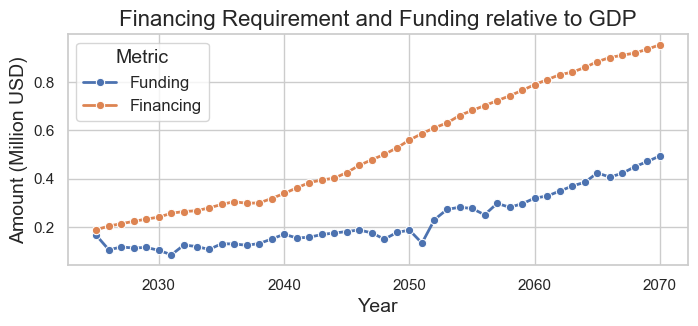

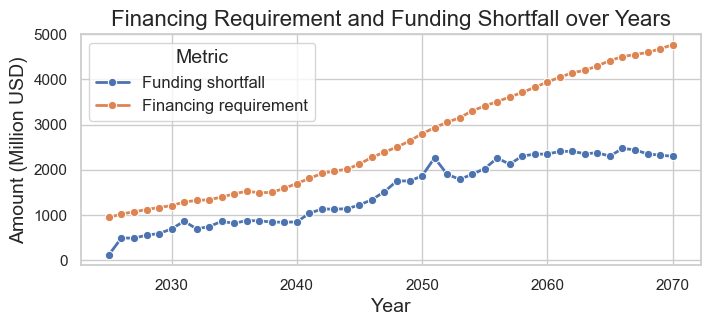

In [214]:

# !/usr/local/bin/python3.11 -m pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_metric_time_series(df, selected_rows, title, xlabel="Year", ylabel="Amount (Million USD)", 
                              legend_title="Metric", fig_size=(8, 3)):
    """
    Plot a time series line chart for selected rows from a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The source DataFrame.
    selected_rows : list
        List of row labels to select (the DataFrame will be transposed).
    title : str
        The title of the plot.
    xlabel : str, default "Year"
        Label for the x-axis.
    ylabel : str, default "Amount (Million USD)"
        Label for the y-axis.
    legend_title : str, default "Metric"
        Title for the legend.
    fig_size : tuple, default (12, 6)
        The size of the figure.
    """
    # 1. Select the rows and transpose the DataFrame.
    df_plot = df.loc[selected_rows].T.reset_index().rename(columns={'index': 'Year'})
    
    # 2. Melt the DataFrame into long format.
    df_long = df_plot.melt(id_vars="Year", var_name="Metric", value_name="Value")
    
    # 3. Ensure the Year column is integer.
    df_long["Year"] = df_long["Year"].astype(int)
    
    # 4. Set seaborn style and create the plot.
    sns.set(style="whitegrid")
    plt.figure(figsize=fig_size)
    ax = sns.lineplot(data=df_long, x="Year", y="Value", hue="Metric", marker="o", linewidth=2)
    
    # 5. Set title and labels.
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    plt.legend(title=legend_title, fontsize=12, title_fontsize=14)
    plt.show()

# Example usage:
# Plot for GDP percentages:
plot_metric_time_series(gdp_percentage, 
                        selected_rows=["Funding", "Financing"], 
                        title="Financing Requirement and Funding relative to GDP")

# Plot for dashboard summary:
plot_metric_time_series(dashboard_summary, 
                        selected_rows=["Funding shortfall", "Financing requirement"], 
                        title="Financing Requirement and Funding Shortfall over Years")


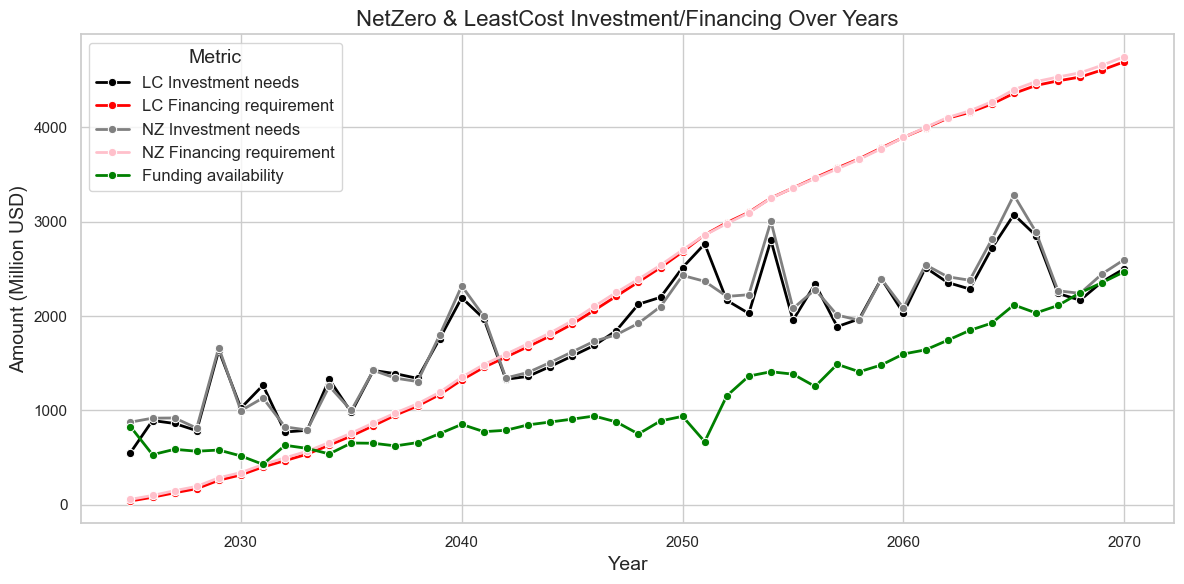

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 假设 df_result 结构类似：
# 行：["NetZero Investment Needs (Million USD)", "NetZero Financing Requirements (Million USD)", ...]
# 列：各年份，如 2025, 2026, ...
# 每个单元格为对应指标在该年份的数值

# 1. 选出我们需要绘制的 5 行，并转置，使“年份”作为行索引
df_plot = pd.DataFrame({
                    "LC Investment needs": lc_needs.loc["Investment needs",:],
                    "LC Financing requirement": lc_needs.loc["Financing Requirements",:],
                    "NZ Investment needs": nz_needs.loc["Investment needs",:],
                    "NZ Financing requirement": nz_needs.loc["Financing Requirements",:],
                    "Funding availability": dashboard_summary.loc["Funding availability",:],
                })

# 2. 重置索引并转换成长格式，方便 seaborn 作图
df_plot = df_plot.reset_index().rename(columns={"index": "Year"})
df_long = df_plot.melt(id_vars="Year", var_name="Metric", value_name="Value")

# 如果 Year 是字符串，可以转成 int（若需要）
# df_long["Year"] = df_long["Year"].astype(int)

# 3. 设置 seaborn 样式并绘制
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 自定义每条线对应的颜色（可根据喜好修改）
palette = {
    "LC Investment needs": "black",
    "LC Financing requirement": "red",
    "Funding availability": "green",
    "NZ Investment needs": "gray",
    "NZ Financing requirement": "pink",
}

ax = sns.lineplot(
    data=df_long,
    x="Year",
    y="Value",
    hue="Metric",
    palette=palette,
    marker="o",
    linewidth=2
)

# 4. 设置标题、坐标轴标签和图例等
ax.set_title("NetZero & LeastCost Investment/Financing Over Years", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Amount (Million USD)", fontsize=14)
plt.legend(title="Metric", fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()



In [216]:
!/usr/local/bin/python3.11 -m pip install plotly

import pandas as pd
import plotly.express as px

def plot_co2_emissions_scenarios(df_emissions):
    """
    Expects a DataFrame `df_emissions` with columns:
      - "Least Cost"
      - "Net Zero"
      - "Emissions Savings"
    and index as the Year (e.g., 2024..2069).
    
    Produces an interactive line chart showing each scenario's emissions
    over the years, with "Emissions Savings" as a dashed line.
    """
    # 1) Reset index so 'Year' becomes a column; rename columns for clarity
    df_plot = df_emissions.reset_index().rename(columns={"index": "Year"})
    
    # 2) Convert to long format for Plotly Express
    df_long = df_plot.melt(
        id_vars="Year", 
        var_name="Scenario", 
        value_name="Emissions"
    )
    
    # 3) Convert Year to int if necessary
    df_long["Year"] = df_long["Year"].astype(int)
    
    # 4) Create an interactive line chart
    fig = px.line(
        df_long,
        x="Year",
        y="Emissions",
        color="Scenario",
        title="Projected CO₂ Emissions by Scenario",
        labels={"Emissions": "Mt CO₂", "Year": "Year"},
    )
    
    # 5) Customize line styles and colors
    #    - 'Emissions Savings': dashed gray
    fig.update_traces(
        selector=dict(name="Emissions Savings"),
        line=dict(dash="dash", color="gray", width=2),
    )
    #    - 'Least Cost': blue
    fig.update_traces(
        selector=dict(name="Least Cost"),
        line=dict(color="blue", width=2),
    )
    #    - 'Net Zero': orange
    fig.update_traces(
        selector=dict(name="Net Zero"),
        line=dict(color="orange", width=2),
    )
    
    # Optional: use a white background
    fig.update_layout(template="plotly_white")
    
    fig.show()

# =======================
# EXAMPLE USAGE:
# =======================
df_emissions = pd.DataFrame({
    "Least Cost": least_cost_summary["co2_emission"],
    "Net Zero": net_zero_summary["co2_emission"],
    "Emissions Savings": -net_zero_summary["co2_emission"]+least_cost_summary["co2_emission"],
}, index=range(2025,2070,1))

plot_co2_emissions_scenarios(df_emissions)



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [217]:
# df_funding_availability_full
# df_funding_availability_full.T
# !/opt/homebrew/bin/python3.12 -m pip install ipykernel -U --user --force-reinstall

In [218]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

width=800
height=600
years = list(dashboard_summary.columns)  # 2025, 2030, 2035, ..., 2070

# df_funding_plot = df_funding_availability_full.T.drop

df_funding_plot = pd.DataFrame({
    "Year": dashboard_summary.columns,
    "Government spending": list(df_funding_availability_full.loc["Government spending", :]),
    "Debt Write-off": list(df_funding_availability_full.loc["Debt Write-off", years]),
    "SOE internal cash generation": list(df_funding_availability_full.loc["SOE internal cash generation", years]),
    "Capital injection": list(df_funding_availability_full.loc["Capital Injection", years]),
    "International Project Grants": list(df_funding_availability_full.loc["International Project Grants", years]),
    "Additional Project Grants": list(df_funding_availability_full.loc["Additional Project Grants", years]),
    "Fossil Fuel Expenditure Savings": list(df_funding_availability_full.loc["Fossil Fuel Expenditure Savings", years]),
    "Carbon Credits": list(df_funding_availability_full.loc["Carbon Credits", years]),

    "Financing Requirement": dashboard_summary.loc["Financing requirement", years], 
    "Funding Availability": dashboard_summary.loc["Funding availability", years]
})

# df_funding_plot.head()
stacked_cols_funding = [
    "Government spending",
    "Debt Write-off",
    "SOE internal cash generation",
    "Capital injection",
    "International Project Grants",
    "Additional Project Grants",
    "Fossil Fuel Expenditure Savings",
    "Carbon Credits"
]

color_map = {
    "Government spending": "#ecf0a2",             # 浅黄色ecf0a2
    "Debt Write-off": "#ecf0a2",                  # 更深一点的浅黄
    "SOE internal cash generation": "#c4da4b",    # 浅青绿
    "Capital Injection": "#c4da4b",               # 黄绿色
    "International Project Grants": "#8bbf3e",    # 偏绿
    "Additional Project Grants": "#8bbf3e",       # 更亮绿
    "Fossil Fuel Expenditure Savings": "#00cc99", # 青绿色
    "Carbon Credits": "#008080"                   # 深青绿
}

def stacked_area_fig(df_stack_plot, stacked_cols,width=800,height=600,color_map=color_map,title="",line_plots=True):
    """
    Sankey stacked area chart
    """

    df_area = df_stack_plot.melt(
        id_vars="Year",
        value_vars=stacked_cols,
        var_name="Source",
        value_name="Value"
    )

    fig = px.area(
        df_area, x="Year", y="Value", color="Source",
        color_discrete_map=color_map,
        title=title,
        labels={"Value": "Million US$", "Year": "Year", "Source": ""},
        template="plotly_white"
    )
    # 先获取 px.area 生成的 fig
    # 在 fig 上 add_trace
    if line_plots :
        # Financing Requirement: 红线
        fig.add_trace(
            go.Scatter(
                x=df_stack_plot["Year"],
                y=df_stack_plot["Financing Requirement"],
                mode="lines+markers",
                name="Financing Requirement",
                line=dict(color="red", width=2),
                marker=dict(color="red", size=5)
            )
        )
    # elif line_plots.lowercase() in ["funding availability","funding"]:
        # Funding Availability: 深绿色线
        fig.add_trace(
            go.Scatter(
                x=df_stack_plot["Year"],
                y=df_stack_plot["Funding Availability"],
                mode="lines+markers",
                name="Funding Availability",
                line=dict(color="darkgreen", width=2),
                marker=dict(color="darkgreen", size=5)
            )
        )
    
    fig.update_layout(
        xaxis=dict(range=[2024, 2071], tickangle=-45),  # 让 x 轴覆盖 2025~2070
        # yaxis=dict(range=[0, 6000]),                   # 根据数据设置适当上限
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="center",
            x=0.2
        ),
        width=width,
        height=height
    )
    return fig
title = "Funding Availability"
fig = stacked_area_fig(df_funding_plot, stacked_cols_funding,width=800,height=600,color_map=color_map,title=title,line_plots=True)
fig.show()
# df_area

In [219]:

# financing_sources
# df_financing_repayments
# df_financing_repayments

In [220]:
import pandas as pd
import numpy as np

years = list(dashboard_summary.columns)  # 2025, 2030, 2035, ..., 2070

# df_funding_plot = df_funding_availability_full.T.drop

df_financing_plot = pd.DataFrame({
    "Year": dashboard_summary.columns,
    "Existing Financing Repayments": list(df_financing_repayments.loc["Existing finance payments (Million USD)", years]),
    "Financing payments for construction of new energy": list(df_financing_repayments.loc["Financing payments for construction of new energy", years]),
    "Fossil fuel retirement cost": list(df_financing_repayments.loc["Financing Payments for retirement of old fossil fuel technologies", years]),
    "Capital Injection Repayments": list(df_financing_repayments.loc["Capital Injection Repayment (Million USD)", years]),
    "Conc IFI (Debt)": list(nz_needs.loc["Debt: Conc_IFI", years]),
    "Conc DPS (Debt)": list(nz_needs.loc["Debt: Conc_DPS", years]),
    "Comm Intl (Debt)": list(nz_needs.loc["Debt: Comm_Intl", years]),
    "Comm Dom (Debt)": list(nz_needs.loc["Debt: Comm_Dom", years]),
    "Conc IFI (Equity)": list(nz_needs.loc["Equity: Conc_IFI", years]),
    "Conc DPS (Equity)": list(nz_needs.loc["Equity: Conc_DPS", years]),
    "Comm Intl (Equity)": list(nz_needs.loc["Equity: Comm_Intl", years]),
    "Comm Dom (Equity)": list(nz_needs.loc["Equity: Comm_Dom", years]),

    "Financing Requirement": dashboard_summary.loc["Financing requirement", years], 
    "Funding Availability": dashboard_summary.loc["Funding availability", years]
})

# df_funding_plot.head()
stacked_cols = [
    "Existing Financing Repayments",
    # "Financing payments for construction of new energy",
    # "Fossil fuel retirement cost",
    "Capital Injection Repayments",
    "Conc IFI (Debt)",
    "Conc DPS (Debt)",
    "Comm Intl (Debt)",
    "Comm Dom (Debt)",
    "Conc IFI (Equity)",
    "Conc DPS (Equity)",
    "Comm Intl (Equity)",
    "Comm Dom (Equity)",
    ]

color_map = {
    "Existing Financing Repayments": "#7F7F7F",      # 中灰
    "Financing payments for construction of new energy": "#a6a6a6",       # 浅灰
    "Fossil fuel retirement cost": "#a6a6a6",             # 浅灰
    "Capital Injection Repayments": "#f2f2f2",       # 金色
    "Conc IFI (Debt)": "#eeb500",                    # 橙色
    "Conc DPS (Debt)": "#ffca21",                    # 橙色
    "Comm Intl (Debt)": "#ffe285",                   # 深橙
    "Comm Dom (Debt)": "#fff5d9",                    # 铜色
    "Conc IFI (Equity)": "#1f4e79",                  # 浅蓝
    "Conc DPS (Equity)": "#2e75b6",                  # 中蓝
    "Comm Intl (Equity)": "#5b9bd5",                 # 青色
    "Comm Dom (Equity)": "#9dc3e6",                  # 深青绿
    "Financing Requirement": "#FF0000",              # 红色 (线)
    "Funding Availability": "#008000"                # 绿色 (线)
}
title = "Financing"
fig = stacked_area_fig(df_financing_plot, stacked_cols,width=800,height=600,color_map=color_map,title=title,line_plots=True)
fig.show()

In [221]:
import pandas as pd
import plotly.express as px
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)
def plot_funding_shortfall_bar_interactive(df, row_label="Funding shortfall", 
                                           title="Projected Funding Shortfall in Absolute Terms"):
    """
    从 DataFrame 中选取指定行 (row_label)，将列视为年份，
    并使用 Plotly 生成交互式柱状图。
    
    参数：
    ----------
    df : pandas.DataFrame
        数据源，含有若干行（指标）和列（年份）。
    row_label : str, default "Funding shortfall"
        需要绘制的行标签。
    title : str, default "Projected Funding Shortfall in Absolute Terms"
        图表标题。
    """
    # 1. 选取该行并转置，使得“Year”成为一列，另一个值列命名为 “Value”
    df_bar = df.loc[row_label,:].T.reset_index().rename(columns={'index': 'Year', row_label: 'Value'})
    data = {
    "Year": list(df_bar["Year"]),
    "Value": list(df_bar["Value"])
        }
    df_bar = pd.DataFrame(data)
    # 3. 用 plotly.express 生成交互式柱状图
    fig = px.bar(
        df_bar,
        x='Year',
        y='Value',
        title=title,
        labels={'Value': 'Million US$', 'Year': 'Year'}
    )

    # 4. 自定义颜色、布局等
    fig.update_traces(marker_color='green')  # 设置柱状图为绿色
    fig.update_layout(
        template='plotly_white',  # 白色背景风格
        xaxis=dict(range=[df_bar['Year'].min(), df_bar['Year'].max()],title='Year'),
        yaxis=dict(title='Million US$')
    )

    fig.show()

# ====================
# 用法示例
# ====================
# 假设你的 DataFrame 叫 dashboard_summary，行中有 "Funding shortfall"，
# 列为 [2025, 2026, ..., 2070] 之类的年份。
plot_funding_shortfall_bar_interactive(dashboard_summary, row_label="Funding shortfall")


In [222]:

# incremental_investment
net_zero_summary.head()
# df_5yr_avg["delta_capital_cost"].values
# df_financing_needs_ffr
# df_category_sum_nz

,variable_cost,fixed_cost,annual_elec_production,co2_emission,carbon_price,capital_cost,total_cost,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,139.3078,224.812,335.7137,0.4391,67.060662,869.3439,1233.4637,3.674154,1.020598,29.446337
2026,83.7825,237.1475,349.8989,0.1041,68.569526,978.1743,1299.1043,3.712799,1.031333,7.138088
2027,118.2583,239.7243,367.1226,0.1982,70.112341,966.7791,1324.7617,3.608499,1.002361,13.896266
2028,115.9271,258.1946,389.7131,0.2378,71.689869,954.408,1328.5297,3.408994,0.946943,17.047851
2029,91.8448,285.0612,420.6769,0.1984,73.302891,1637.2812,2014.1872,4.787967,1.329991,14.543293


In [223]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

width = 800
height = 600
df_long_nz = df_category_sum_nz.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
df_long_incremental = incremental_investment.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
years = df_category_sum_nz["Year"]

# ========== 第二步：创建 2行 × 4列 的子图布局 ==========
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        "Plot 1: Investment Needs",       # 子图1 标题
        "Plot 2: Cost of Capital",        # 子图2 标题
        "Plot 3: Borrowed Sources",       # 子图3 标题
        "Plot 4: Scenario Difference",    # 子图4 标题
        "Plot 5: Future Needs by Source", # 子图5 标题
        "Plot 6: Funding Shortfall",      # 子图6 标题
        "Plot 7: Additional Metrics",     # 子图7 标题
        "Plot 8: Another Metric"          # 子图8 标题
    ]
)

color_map = {

    "Biomass": "#ff9900",       # 橙色
    "Geothermal": "#66ccff",    # 浅蓝
    "Solar PV": "#ffd700",      # 金色
    "Wind": "#66ff66",          # 亮绿色
    "Onshore Wind": "#66ff66",
    "Offshore Wind": "#66ff66",
    "Nuclear": "#999999",       # 灰色
    "Coal": "#333333",          # 深灰
    "Gas": "#ff6666",           # 浅红
    "Oil": "#cc6600",           # 深橙

    "Hydropower": "#3399FF",    # 水蓝
    "CSP": "#FFB84D",           # 浅橙金
    "Distribution": "#808080",  # 中灰
    "Transmission": "#9966FF",  # 紫色
    "Other": "#BEBEBE"          # 银灰
}

# ========== 第三步：为每个子图添加示例图表 ==========

# ---------- 子图1 (row=1, col=1) ----------
fig_area1 = px.area(
    df_long_nz, 
    x="Year", 
    y="InvestmentNeed", 
    color="Technology", 
    color_discrete_map=color_map,
    title="Projected Investment Needs to Reach Net Zero by 2050",
    labels={"InvestmentNeed": "Million US$", "Year": "Year"}
)
fig_area1.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

fig_area2  = px.bar(
    df_long_incremental, 
    x="Year",
    y="InvestmentNeed",
    color="Technology",
    color_discrete_map=color_map,
    barmode="relative",  # 关键参数：堆叠柱状
    title="Additional Capital Cost of Net Zero",
    labels={"Cost": "Million US$", "Year": "Year"}
)

fig_area2.update_layout(
    template="plotly_white",
    # 若想让 x 轴从 2025 到 2070 全覆盖，可以手动设置 range
    xaxis=dict(range=[2024.5, 2070.5]),
    # yaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor="black")
    width=width,
    height=height
)
fig_area2.update_layout(
    template="plotly_white",    
    )


df_cost = pd.DataFrame({
    "Scenario": ["NetZero", "NetZero", "NetZero"],
    "Cost Type": ["Capital Cost", "O&M Costs (Variable)", "O&M Costs (Fixed)"],
    "Value": [
        net_zero_summary["capital_cost"].sum(),
        net_zero_summary["variable_cost"].sum(),
        net_zero_summary["fixed_cost"].sum()
        ]  # 单位: Million US$
    })

fig_area3 = px.bar(
    df_cost,
    x="Scenario",
    y="Value",
    color="Cost Type",
    barmode="relative",  # 堆叠方式
    title="Total Undiscounted Scenario Cost 2025 to 2070",
    labels={"Value": "Million US$", "Scenario": ""}
)

fig_area3.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

df_diff = pd.DataFrame({
    "Year": df_5yr_avg["Year"],
    "Capital Cost":  list(df_5yr_avg["delta_capital_cost"].values),
    "Variable Cost": list(df_5yr_avg["delta_variable_cost"].values),
    "Fixed Cost":    list(df_5yr_avg["delta_fixed_cost"].values),
    "Cost of Carbon":list(df_5yr_avg["emission_saving"].values),
    # "Net Benefits":  df_5yr_avg["delta_capital_cost"]
})
# df_diff = pd.DataFrame({
#     "Year": df_5yr_avg["Year"],
#     "Capital Cost": list(df_5yr_avg["delta_capital_cost"].values),
#     "Variable Cost": [0,   20, 8,   0,   30,  0,   0,   0,   0  ],
#     "Fixed Cost":    [0,   0,  7,   0,   0,   0,   0,   0,   0  ],
#     "Cost of Carbon":[0,   0,  0,   30,  37,  40,  50,  60,  70 ],
#     "Net Benefits":  [-46, 20, 15, 47,  67, 107, 221, 275, 370]
# })
df_diff_long= df_diff.melt(
    id_vars=["Year"],  # Net Benefits 单独保留
    value_vars=["Capital Cost", "Variable Cost", "Fixed Cost", "Cost of Carbon"],
    var_name="Cost Type",
    value_name="Value"
)
df_diff["Net Benefits"] = df_diff["Capital Cost"] + df_diff["Variable Cost"] + df_diff["Fixed Cost"] + df_diff["Cost of Carbon"]

color_map_costs = {

    "Cost of Carbon": "#66ff66",          # 亮绿色

    "Variable Cost": "#cc6600",           # 深橙

    "Capital Cost": "#3399FF",    # 水蓝
    "Fixed Cost":    "#66ccff"
}
# 绘制堆叠柱状图
fig_area4 = px.bar(
    df_diff_long,
    x="Year",
    y="Value",
    color="Cost Type",
    color_discrete_map=color_map_costs,
    barmode="relative",  # 堆叠  
    title="Differential benefits and costs of NZ vs BAU (Million US$)",
    labels={"Value": "Million US$", "Year": "Year"}
)
fig_area4.add_trace(
    go.Scatter(
        x=df_diff["Year"],           # 与柱子的 X 相同
        y=df_diff["Net Benefits"],   # 纵坐标为 Net Benefits
        mode="markers+text",    # 同时画点和文字
        text=df_diff["Net Benefits"].apply(lambda x: f"{round(x)}").astype(str),  # 显示数值文本
        textposition="top center",            # 文字显示在点的上方
        marker=dict(
            symbol=141,       # 关键：水平线符号'line-ew', 141, '141'
            size=20,                # 线的长度由 size 决定
            color="red",
        ),
        name="Net Benefits"     # 在图例中显示的名称
    )
)
fig_area4.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis=dict(range=[2020.5, 2070.5]),
    width=width,
    height=height
    )


# 1) 准备数据
df_stranded_cost = pd.DataFrame({
    "Fuel": ["Coal", "Gas", "Oil"],
    "Extra Stranded Cost": [0, 0, 0]  # 仅作示例：煤炭=750, 天然气=0, 石油=0
})
since_year = 2025
for tech in  df_stranded_cost["Fuel"]:
    # 从since_year开始计算累计搁浅成本
    df_stranded_cost.loc[df_stranded_cost["Fuel"]==tech, "Extra Stranded Cost"]=df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,(tech,tech)].sum()
# 2) 绘制柱状图
fig_stranded_cost = px.bar(
    df_stranded_cost,
    x="Fuel",
    y="Extra Stranded Cost",
    title="Extra Stranded Cost Compensation of Net Zero",
    labels={"Extra Stranded Cost": "Million US$", "Fuel": ""},
    text="Extra Stranded Cost"  # 在柱子上显示数值
)

# 3) 美化布局
fig_stranded_cost.update_layout(
    template="plotly_white",
    yaxis=dict(range=[0, 800]),  # 根据数据适当调整上限
    width=width,
    height=height
    )

# 让数值显示在柱子上方
fig_stranded_cost.update_traces(textposition="outside")
####################################
# 只计算煤炭、天然气和石油的搁浅成本总和
stranded_cost = df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,("Total","Total")].copy()
    
df_plot = pd.DataFrame({
    "Year": df_category_sum_nz["Year"],
    "Net Zero Financing Needs": df_category_sum_nz.copy().drop('Year', axis=1).sum(axis=1),
    "Stranded Cost Compensation": list(stranded_cost)
})

fig_needs_by_source = px.bar(
    df_plot,
    x="Year",
    y=["Net Zero Financing Needs", "Stranded Cost Compensation"],
    barmode="relative",
    color_discrete_sequence=["grey", "black"],
    title="Future Investment Needs by Source",
    labels={"value": "Million US$", "variable": ""},  # 调整图例/轴标签
    template="plotly_white",
)

# 给所有柱子加黑色边框
fig_needs_by_source.update_traces(marker=dict(line=dict(color="black", width=1)))

# 调整布局，比如让图例在下方、改宽高等
fig_needs_by_source.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,  # 图例放在下方
        xanchor="center",
        x=0.5
    ),
    xaxis=dict(range=[2024, 2070.5]),
    
    width=width,
    height=height
)

df = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["cost_of_elec"],
    "LeastCost": least_cost_summary["cost_of_elec"],
})

# 将 NetZero 和 LeastCost 列 melt 成 “Scenario” 和 “Cost” 两列
df_long_elec_cost = df.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)
# 现在 df_long 的结构类似：
#   Year   Scenario   Cost
# 0 2025   NetZero    14
# 1 2030   NetZero    15
# 2 2035   NetZero    12
# ... 
# (后面还有 LeastCost 行)

# 用 px.line 绘制
fig_elec_cost = px.line(
    df_long_elec_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Average Cost of Electricity US$/TWh",
    labels={"Cost": "US$/TWh", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  # 自定义颜色
)

fig_elec_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # 根据你的数据范围，可设定或让 Plotly 自动
    width=width,
    height=height
)


df_capital = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["capital_cost"],
    "LeastCost": least_cost_summary["capital_cost"],
})

# 将 NetZero 和 LeastCost 列 melt 成 “Scenario” 和 “Cost” 两列
df_capital_cost = df_capital.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)
# 现在 df_long 的结构类似：
#   Year   Scenario   Cost
# 0 2025   NetZero    14
# 1 2030   NetZero    15
# 2 2035   NetZero    12
# ... 
# (后面还有 LeastCost 行)

# 用 px.line 绘制
fig_capital_cost = px.line(
    df_capital_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Capital Cost NZ vs LC",
    labels={"Cost": "Million US$", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  # 自定义颜色
)

fig_capital_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # 根据你的数据范围，可设定或让 Plotly 自动
    width=width,
    height=height
)


# fig.update_layout(template="plotly_white")
# fig_area1.show()
# fig_area2.show()
# fig_area3.show()
# fig_area4.show()
# fig_stranded_cost.show()
# fig_needs_by_source.show()
fig_elec_cost.show()
fig_capital_cost.show()

# # 2) 创建子图布局
# fig_sub = make_subplots(rows=1, cols=2, 
#     subplot_titles=["Scenario A", "Scenario B"])

# # 3) 把 area1 的所有 trace 加到 (row=1, col=1)
# for trace in fig_area1.data:
#     fig_sub.add_trace(trace, row=1, col=1)

# # 4) 把 area2 的所有 trace 加到 (row=1, col=2)
# for trace in fig_area2.data:
#     fig_sub.add_trace(trace, row=1, col=2)

# # 5) 全局布局
# fig_sub.update_layout(height=600, width=1200, title="Two Area Charts in Subplots")
# fig_sub.update_layout(template="plotly_white")

# fig_sub.show()
# df_diff


### Funding Availability Projections

In [224]:
df_funding_envelope.index



Index([                2010,                 2011,                 2012,
                       2013,                 2014,                 2015,
                       2016,                 2017,                 2018,
                       2019,                 2020,                 2021,
                       2022,                 2023,                 2024,
           'Annual Average', 'Annual Growth Rate'],
      dtype='object', name='Year')

In [225]:
import plotly.express as px
year_idx = [x for x in df_funding_envelope.index
 if isinstance(x, (int, float))]
df_funding_historic_plot = df_funding_envelope.loc[year_idx]

df_funding = pd.DataFrame({
    "Year": year_idx,  # 2010 ~ 2023
    "Government Spending": list(df_funding_historic_plot["Budget"]),
    "SOE internal cash generation":  list(df_funding_historic_plot["SOE Gen."]),
    "International Grants":  list(df_funding_historic_plot["Grant"])
})
fig = px.bar(
    df_funding,
    x="Year",
    y=["Government Spending", "SOE internal cash generation", "International Grants"],
    barmode="relative",  # 堆叠
    title="Historic Sources of Funding Availability for Energy Investments",
    labels={"value": "Million US$", "variable": ""},  # 自定义轴标签和图例标题
    template="plotly_white",
    # 可自定义颜色序列
    color_discrete_sequence=["#fcfab2","#c4b97a", "#d7ea64" ]
)

fig.update_layout(
    xaxis=dict(dtick=1),   # x 轴每年一个刻度（若需要）
    yaxis=dict(range=[0, 800]),  # 根据数据可选地设置上限
    width=width,
    height=height,
    legend=dict(
    orientation="h",   # 水平排列
    yanchor="bottom",
    y=-0.2,            # 图例相对于整个图表的纵向位置（可根据需要调整）
    xanchor="center",
    x=0.5              # 图例居中
    )
)

fig.show()
fig_funding_projection = stacked_area_fig(df_funding_plot, stacked_cols_funding,width=800,height=600,color_map=color_map,title=title,line_plots=0)
fig_funding_projection.show()

### Historic Financing


In [226]:
institution_shares #= fbs.get_institution_shares()
financing_sector_shares #= fbs.get_financing_sector_shares()
# repayment_statistics
hd.get_financing_source_shares()


,Historical,Projected
Conc_IFI,0.743813,0.743813
Conc_DPS,0.111098,0.111098
Comm_Intl,0.121813,0.121813
Comm_Dom,0.023275,0.023275


In [227]:
df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].T
df_source =hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T
df_source

,Conc_IFI,Conc_DPS,Comm_Intl,Comm_Dom
Historical,0.743813,0.111098,0.121813,0.023275


In [228]:
import pandas as pd

df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].to_frame().T
df_origin = financing_sector_shares.loc[["Domestic", "International"],:].T
df_source = hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T

df_provider["Category"] = "Provider"
df_instrument["Category"] = "Instrument"
df_origin["Category"] = "Origin"
df_source["Category"] = "Source"

# 2. 合并 4 个 DataFrame
df_wide = pd.concat([df_provider, df_instrument, df_origin, df_source], ignore_index=True)

# 3. 使用 melt 将宽表转换为长表
#    只保留 "Category" 为 id_vars，其他列均转换为 "Subcategory" 与 "Value"
df_long = df_wide.melt(
    id_vars="Category",
    var_name="Subcategory",
    value_name="Value"
)

# 如果某些行的 Value 为 NaN（例如因为原数据中不存在），可以丢弃
df_long = df_long.dropna(subset=["Value"]).reset_index(drop=True)

import plotly.express as px
# color_map = {
#     "Conc IFI": "#99CCFF",
#     "Conc DPS": "#FFCC99",
#     "Comm Intl": "#FF9999",
#     "Comm Dom": "#FFFF99",
#     "Domestic": "#FFCC66",
#     "International": "#66CC99",
#     "Debt": "#99FF99",
#     "Equity": "#66CC66",
#     "Public": "#CCCCFF",
#     "Private": "#CC99FF"
# }

fig = px.bar(
    df_long,
    x="Value",
    y="Category",
    color="Subcategory",
    text="Subcategory",
    orientation="h",
    barmode="relative",  # 堆叠
    color_discrete_map=color_map,
    title="Historic Sources of Finance for Energy Investments 2010-2024",
    labels={"Value": "Percentage (%)", "Category": ""}
)
fig.update_traces(
    # ,       # 显示分类名
    textposition="inside",    # 文字放在柱子内部
    insidetextanchor="middle" # 垂直居中（可选）
)
# 若想把 X 轴限制在 0~100
fig.update_xaxes(range=[0, 1])

fig.update_layout(
    template="plotly_white",
    showlegend = False,
    width = width,
    height = height,
    # margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()


In [229]:
# repayment_statistics

In [230]:
import plotly.graph_objects as go
import pandas as pd
volume={"Conc_IFI": 0,
    "Conc_DPS":  0,
    "Comm_Intl":  0,
    "Comm_Dom":   0}
df_raw = pd.DataFrame({
    "MarketElement": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Market Element"]),
    "volume": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Volume (USD)"]),
    "color": ["#ffbbbc", "#ff7b7b", "#ff0000", "#c00000"]
},index=volume.keys())

df_sorted = df_raw.sort_values("MarketElement")
df_plot = df_sorted.copy()


base = df_raw.loc[:,"volume"].cumsum()-df_raw.loc[:,"volume"]
# for key, v in volume.items():
#     y_val = df_raw.loc[key,"MarketElement"]
#     x_val = df_raw.loc[key,"volume"]
#     print(base)
    # 1) 粉色段

fig = go.Figure()

a = df_plot.loc[:,"volume"].cumsum()
for key, v in volume.items():
    y_val = df_plot.loc[key,"MarketElement"]
    x_val = df_plot.loc[key,"volume"]#+base[key]
    print([y_val])
    fig.add_trace(
        go.Bar(
            x=[x_val],          # bar长度
            y=[y_val],
            base= base[key],
            orientation="h",
            marker_color=df_plot.loc[key,"color"],
            name=key,
            width=y_val,               # 设置条形在 y 方向上的厚度为 0.3 个单位
            offset=-y_val              # 向上偏移 0.15，使条形下边缘对齐 y_val
        )
    )
    # fig.add_shape(
    #     type="rect",
    #     x0=base[key], x1=x_val,       # 横向区间
    #     y0=0, y1=y_val,       # 纵向区间
    #     fillcolor=df_raw.loc[key,"color"],          # 颜色
    #     opacity=1,               # 透明度
    #     line_width=0               # 去掉边框线
    # )
    # base += x_val
    # # 2) 红色段
    # fig.add_trace(
    #     go.Bar(
    #         x=[comm_val],         # bar长度
    #         y=[y_val],
    #         base=[conc_val],      # 起点是 conc_val
    #         orientation="h",
    #         marker_color="red",
    #         name="Comm"
    #     )
    # )

fig.update_layout(
    title="Merit order of Financing Sources by Grant Element between 2010-2024",
    showlegend=True,
    barmode="relative",   # 不要stack或group，直接覆盖
    xaxis=dict(title="Amount ($)", range=[0, 9000]),
    yaxis=dict(title="Market Element", range=[0,1], zeroline=True),
    template="plotly_white",
    width=width,
    height=height
)

fig.show()
# base

[np.float64(0.1938632721227665)]
[np.float64(0.22868714221826006)]
[np.float64(0.6610318464016289)]
[np.float64(0.7523872975209684)]


In [231]:
# institution_shares

In [232]:
color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4"
}
df_institution_shares_plot = pd.DataFrame({
    "Financier": institution_shares.index,
    "Share": institution_shares["Share"]
})
df_institution_shares_plot[""] = ""

def single_bar_plot(df_plot, x, y, color_map, title="", labels="",width=800,height=600):
    fig = px.bar(
        df_plot,
        x=x,
        y=y,
        color="Financier",
        orientation="h",
        barmode="stack",
        color_discrete_map=color_map,
        title=title,
        # labels={"Share": "Percentage", "Row": ""}
    )
    if max(df_plot[x]) <1:
        fig.update_layout(
            xaxis=dict(range=[0,1], tickformat=".0%"),
            width=width,
            height = height,
            legend=dict(
                orientation="h",   # 水平排列
                yanchor="bottom",
                y=-0.3,            # 图例相对于整个图表的纵向位置（可根据需要调整）
                xanchor="center",
                x=0.5              # 图例居中
                )   
        )
    else:
        fig.update_layout(
            width=width,
            height = height,
            legend=dict(
                orientation="h",   # 水平排列
                yanchor="bottom",
                y=-0.3,            # 图例相对于整个图表的纵向位置（可根据需要调整）
                xanchor="center",
                x=0.5              # 图例居中
                )   
        )
    return fig
fig = single_bar_plot(df_institution_shares_plot, "Share", "", color_map, "Historic Proportion of Contributions from Financier 2010-2024", {"Share": "Percentage", "Row": ""})
fig.show()

In [233]:
repayment_statistics
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_new = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]

# # 如果想改列名，可以 rename
# df_new = df_new.rename(columns={"value": "Amount"})

In [234]:
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_source_share = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]

df_source_share = df_source_share.reset_index() # 将原本的多级行索引变成普通列
#  ["level_0", "level_1", "value"]
# df_source_share.columns
# # 合并两列为你想要的格式，比如 "Conc_IFI (Debt)"
df_source_share["merged"] = df_source_share["level_1"] + " (" + df_source_share["level_0"] + ")"

color_map_source_share = ["#7f6000", "#bf9000", "#ffc000","#ffd966","#ffe699","#fff2cc","#2f5597","#4472c4"]
color_map_source_share = {k:v for k,v in zip(df_source_share["merged"].unique(), color_map_source_share)}

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]/df_source_share["Volume (USD)"].sum()
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share, "", {"Share": "Percentage", "Row": ""})
fig.show()

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share, "", {"Share": "Percentage", "Row": ""})
fig.show()

In [235]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.405901,0.286073,0.990458,0.009542
Multilateral Agency,0.317207,0.209471,0.988280,0.011720
Foreign Government,0.016177,0.093944,1.000000,0.000000
National Government,0.100719,0.434034,0.144891,0.855109
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.023221,0.480228,0.791228,0.208772
Commercial Bank,0.031322,0.549836,1.000000,0.000000
Private Equity Fund,0.105453,1.000000,0.096183,0.903817


In [236]:

def plot_market_element_by_financier(df, color_map,
                                           title="Market Elements of Finance for Energy Investments 2010-2024 by Financier"):
    """
    从 DataFrame 中选取指定行 (row_label)，将列视为年份，
    并使用 Plotly 生成交互式柱状图。
    
    参数：
    ----------
    df : pandas.DataFrame
        数据源，含有若干行（指标）和列（年份）。
    row_label : str, default "Funding shortfall"
        需要绘制的行标签。
    title : str, default "Projected Funding Shortfall in Absolute Terms"
        图表标题。
    """
    # 1. 选取该行并转置，使得“Year”成为一列，另一个值列命名为 “Value”
    df_bar = df
    data = {
    "Financier": list(df_bar.index),
    "Value": list(df_bar["Market Element"])
        }
    df_bar = pd.DataFrame(data)
    # 3. 用 plotly.express 生成交互式柱状图
    fig = px.bar(
        df_bar,
        x='Financier',
        y='Value',
        title=title,
        color="Financier",
        color_discrete_map=color_map,
        category_orders={"Financier": list(color_map.keys())},  # 指定类别顺序
        labels={'Value': 'Million US$', 'Financier': 'Financier'},
    )
    unique_financiers = df_bar["Financier"].unique()
    fig.update_layout(
        template='plotly_white',  # 白色背景风格
        xaxis=dict(range=[df_bar['Financier'].min(), df_bar['Financier'].max()],title='Year'),
        yaxis=dict(title='Million US$')
    )

    fig.show()

color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4"
}

row_label = list(institution_shares.index)
plot_market_element_by_financier(institution_shares["Market Element"].to_frame(),color_map=color_map)
# row_label

In [252]:
fbs.get_technology_stats()
# historical

,IRR,Volume of Finance,Interest Rate,Debt Share,Equity Share,WACC
Technology,,,,,,
Geothermal,0.200115,4410.840921,0.035600,0.756456,0.243544,0.075667
Solar,0.050575,783.025000,0.037162,0.747792,0.252208,0.040545
Biomass,0.120000,229.000000,0.061521,0.615721,0.384279,0.083993
Transmission,0.132620,1977.370902,0.023646,0.878075,0.121925,0.036933
Non-Renewable,0.149000,304.600000,0.082257,0.864905,0.135095,0.091274
Oil,0.185000,108.000000,0.073025,0.750000,0.250000,0.101019
Distribution,0.092178,1769.357838,0.023167,0.973866,0.026134,0.024971
Wind,0.153333,1165.380000,0.032506,0.799585,0.200415,0.056722
Hydro,0.053000,85.600000,0.052250,0.642523,0.357477,0.052518


In [238]:
import pandas as pd
import plotly.express as px

# 创建数据框

df_technology_financing = fbs.get_technology_stats()
df_technology_financing["Technology"] = df_technology_financing.index

# 将数据转换成长格式
df_melted = df_technology_financing.melt(id_vars=["Technology"], value_vars=["IRR", "Interest Rate", "WACC"],
                     var_name="Metric", value_name="Value")

color_map = {"IRR": "#00ffcc", "Interest Rate": "#ffc000", "WACC": "#ff99ff"}    
# 创建柱状图
fig = px.bar(
    df_melted,
    x="Technology",
    y="Value",
    color="Metric",
    title="Historic Cost of Financing 2010-2024",
    barmode="group",
    color_discrete_map=color_map,
    labels={"Value": "Percentage", "Technology": "Technology"},
    
)
fig.update_traces(marker=dict(line=dict(color='black', width=2)))

# 调整 Y 轴为百分比格式
fig.update_layout(
    yaxis_tickformat=".0%",
    width=width,
    height=height,
    )

# 显示图表
fig.show()


In [239]:
terms_debt_finance = repayment_statistics.loc["Debt",:]
terms_debt_finance
# Weighted average not used in EXCEL

,Volume (USD),Interest rate,Term,Grace period,Average Annual Payment,Debt Share,Equity Share,Market Element,Grant Element
Total financing volumes,8775.314587,0.027191,26.45821,6.703122,8.752599,NaN,NaN,0.223720,0.776280
Conc_IFI,8033.914587,0.022211,27.250361,6.921876,8.905095,NaN,NaN,0.193863,0.806137
Conc_DPS,205.98,0.026511,22.641732,7.098791,4.009441,NaN,NaN,0.228687,0.771313
Comm_Intl,484.02,0.097009,15.774761,2.817094,8.481244,NaN,NaN,0.661032,0.338968
Comm_Dom,51.4,0.150913,18.540856,7.519455,6.480112,NaN,NaN,0.752387,0.247613


In [240]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.405901,0.286073,0.990458,0.009542
Multilateral Agency,0.317207,0.209471,0.988280,0.011720
Foreign Government,0.016177,0.093944,1.000000,0.000000
National Government,0.100719,0.434034,0.144891,0.855109
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.023221,0.480228,0.791228,0.208772
Commercial Bank,0.031322,0.549836,1.000000,0.000000
Private Equity Fund,0.105453,1.000000,0.096183,0.903817


In [241]:
# 示例数据

def debt_equity_plot(df, title, width = 800, height = 600):
    # 重新转换数据，使其适用于Plotly的Stacked Bar Chart
    df_melted = df.melt(id_vars=["Financier"], 
                        value_vars=["Debt Share", "Equity Share"],
                        var_name="Type", value_name="Share")

    # 使用 Plotly Express 绘制水平堆积条形图
    fig = px.bar(
        df_melted,
        x="Share",
        y="Financier",
        color="Type",
        orientation="h",  # 水平条形图
        title=title,
        color_discrete_map={"Debt Share": "#ffc000", "Equity Share": "#2f5597"}  # 自定义颜色
    )

    # 调整布局
    fig.update_layout(
        xaxis_title="Percentage",
        yaxis_title="",
        xaxis=dict(tickformat=".0%", showgrid=True),
        barmode="stack",
        legend_title_text="",
        width=width,
        height=height
    )

    # 显示图表
    return fig
    
institution_shares.sort_values("Equity Share", inplace=True)

data = {
    "Financier": institution_shares.index,
    "Debt Share": institution_shares["Debt Share"],
    "Equity Share": institution_shares["Equity Share"]
}
df = pd.DataFrame(data)    
debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Financier")


In [242]:
repayment_statistics.loc["Summary",["Debt Share","Equity Share"]]

,Debt Share,Equity Share
Total financing volumes,0.798978,0.201022
Conc_IFI,0.983412,0.016588
Conc_DPS,0.168807,0.831193
Comm_Intl,0.361778,0.638222
Comm_Dom,0.201066,0.798934


In [243]:
filtered_data = repayment_statistics.loc["Summary",["Debt Share","Equity Share"]].copy()
filtered_data.sort_values("Equity Share", inplace=True)
filtered_data = filtered_data.loc[filtered_data.index != "Total financing volumes",:]
data = {
    "Financier": filtered_data.index,
    "Debt Share": filtered_data["Debt Share"],
    "Equity Share": filtered_data["Equity Share"]
}
df = pd.DataFrame(data)    
debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")

In [244]:
technology_debt_equity_share = fbs.get_technology_stats()[["Debt Share", "Equity Share"]]
technology_debt_equity_share.sort_values("Equity Share", inplace=True)
data = {
    "Financier": technology_debt_equity_share.index,
    "Debt Share": technology_debt_equity_share["Debt Share"],
    "Equity Share": technology_debt_equity_share["Equity Share"]
}
df = pd.DataFrame(data)    
debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")

### Future Financing Needs Projections

In [245]:
years = list(nz_needs.columns)
df_stack_nz_needs = pd.DataFrame({
    "Year": years,
    "Conc IFI (Debt)": list(nz_needs.loc["Debt: Conc_IFI", years]),
    "Conc DPS (Debt)": list(nz_needs.loc["Debt: Conc_DPS", years]),
    "Comm Intl (Debt)": list(nz_needs.loc["Debt: Comm_Intl", years]),
    "Comm Dom (Debt)": list(nz_needs.loc["Debt: Comm_Dom", years]),
    "Conc IFI (Equity)": list(nz_needs.loc["Equity: Conc_IFI", years]),
    "Conc DPS (Equity)": list(nz_needs.loc["Equity: Conc_DPS", years]),
    "Comm Intl (Equity)": list(nz_needs.loc["Equity: Comm_Intl", years]),
    "Comm Dom (Equity)": list(nz_needs.loc["Equity: Comm_Dom", years])
})

stacked_cols=list(df_stack_nz_needs.columns[1:])
#["Debt: Conc_IFI", "Debt: Conc_DPS", "Debt: Comm_Intl", "Debt: Comm_Dom", 
#"Equity: Conc_IFI", "Equity: Conc_DPS", "Equity: Comm_Intl", "Equity: Comm_Dom"]

color_map = {
    "Conc IFI (Debt)": "#7f6000",
    "Conc DPS (Debt)": "#bf9000",
    "Comm Intl (Debt)": "#ffc000",
    "Comm Dom (Debt)": "#ffe699",
    "Conc IFI (Equity)": "#203864",
    "Conc DPS (Equity)": "#2f5597",
    "Comm Intl (Equity)": "#4472c4",
    "Comm Dom (Equity)": "#b4c7e7" 
}
colors = list(color_map.values())
color_map_nz_repay = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

f = stacked_area_fig(
    df_stack_nz_needs, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_nz_repay,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
f

In [246]:
df_debt_stock

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Conc_IFI,621.699662,1272.992234,1924.584772,2496.401062,3691.967432,4396.678225,5176.976346,5706.042292,6183.742963,6975.820834,...,25390.717262,25791.681954,26137.14902,26774.144187,27716.500628,28355.551521,28532.737876,28681.149023,28948.958017,29278.178091
Conc_DPS,15.938343,32.633335,49.333756,63.98636,94.628527,112.68289,133.228795,147.899829,161.115246,182.135132,...,671.97195,686.041737,699.778235,721.239051,750.779708,772.333368,781.350629,789.357385,800.519275,813.989516
Comm_Intl,37.402658,76.499485,114.366089,145.729183,212.786707,248.340064,286.532582,308.203586,325.169607,359.390502,...,770.171138,761.620103,747.069465,747.628123,765.893841,764.4675,731.641811,692.965173,660.403886,633.723868
Comm_Dom,3.967885,8.108369,12.230573,15.818168,23.367593,27.742377,32.699265,36.09108,39.111328,44.049794,...,48.635388,37.022888,22.77815,7.834427,-7.938845,-28.983284,-56.784187,-88.932199,-124.858268,-165.623471
Total,679.008549,1390.233422,2100.515189,2721.934773,4022.750259,4785.443557,5629.436988,6198.236788,6709.139144,7561.396262,...,26881.495738,27276.366682,27606.77487,28250.845788,29225.235332,29863.369105,29988.946129,30074.539382,30285.022911,30560.268004


In [247]:
years = list(df_debt_stock.columns)
df_stack_debt_stock = pd.DataFrame({
    "Year": years,
    "Conc IFI": list(df_debt_stock.loc["Conc_IFI", years]),
    "Conc DPS": list(df_debt_stock.loc["Conc_DPS", years]),
    "Comm Intl": list(df_debt_stock.loc["Comm_Intl", years]),
    "Comm Dom": list(df_debt_stock.loc["Comm_Dom", years]),
})
stacked_cols=list(df_stack_debt_stock.columns[1:])
#["Debt: Conc_IFI", "Debt: Conc_DPS", "Debt: Comm_Intl", "Debt: Comm_Dom", 
#"Equity: Conc_IFI", "Equity: Conc_DPS", "Equity: Comm_Intl", "Equity: Comm_Dom"]

color_map = {
    "Conc IFI": "#bf9000",
    "Conc DPS": "#ffd966",
    "Comm Intl": "#2f5597",
    "Comm Dom": "#8faadc",
}
colors = list(color_map.values())
color_map_debt_stock = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

fig_debt_stock = stacked_area_fig(
    df_stack_debt_stock, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_debt_stock,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
fig_debt_stock

In [248]:

years = list(df_financing_repayments.columns)
df_stack_future_repayment = pd.DataFrame({
    "Year": years,
    "Retirement of old fossil fuel technologies": list(df_financing_repayments.loc["Financing Payments for retirement of old fossil fuel technologies", years]),
    "Existing finance payments": list(df_financing_repayments.loc["Existing finance payments (Million USD)", years]),
    "Construction of new energy": list(df_financing_repayments.loc["Financing payments for construction of new energy", years]),
})
stacked_cols=list(df_stack_future_repayment.columns[1:])

color_map = {
    "Financing Payments for retirement of old fossil fuel technologies": "#ff0003",
    "Existing finance payments": "#ff9999",
    "Financing payments for construction of new energy": "#a5a5a5",
}
colors = list(color_map.values())
color_map_future_repayment = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

fig_future_repayment = stacked_area_fig(
    df_stack_future_repayment, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_future_repayment,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
fig_future_repayment

### Financial Instrument Projections

In [249]:
import plotly.express as px
instruments = [
            "Debt Write-Off", "Carbon Credit", "Grant Element",
            "Combination", "Loan", "Grant"
        ]
df_merged = pd.concat([
        df_debt_write_off_summary.sum(axis=1),
        df_carbon_credits_summary.sum(axis=1),
        df_grant_element_summary.sum(axis=1),
        df_grant_loan.sum(axis=1),
        df_loan.sum(axis=1),
        df_grants.sum(axis=1),   
     ], 
    keys=instruments, 
    names=["Instruments"]
    )
# print(df_merged.index)
df_merged = df_merged.drop("Undiscounted",level=1).reset_index(level="Instruments",drop=False).reset_index()
# df_merged.drop("Undiscounted")
df_long = df_merged.melt(
    id_vars=["Instruments","index"],   # 这两列保持不变
    value_name="Value",
    ignore_index=False
)
# df_long.index.name="Party"
df_long
fig = px.bar(
    df_long,
    x="Value",
    y="Instruments",
    color="index",             # Donor / Recipient
    color_discrete_map = {"Recipient": "#ed7d31", "Donor": "#4472c4"},
    orientation="h",           # 水平条形图
    barmode="relative",           # 分组显示
    title="Financial Instruments from the Donor and Recipient Per"
)

# 美化布局
fig.update_layout(
    template="plotly_white",
    xaxis=dict(
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="black"
    ),
    # 若想让 Instrument 顺序和 DataFrame 保持一致，可设置 categoryorder='array'
    yaxis=dict(
        categoryorder="array",
        categoryarray= instruments,
    ),
    height = height,
    width = width,
    legend=dict(
        orientation="h",   # Make legend horizontal
        yanchor="bottom",
        y=-0.3,            # Push legend a bit below the chart
        xanchor="center",
        x=0.5,
        title_text = ""
    )
)


fig.show()


In [250]:

def instrument_line_plots(df,method="Grant"):
    df = df.T
    fig = px.line(
        df,
        x=df.index,
        y=["Donor", "Recipient"],  # 选择多列一起画
        title=f"{method} Methodology",
        labels={"value": "Million USD$", "": "Year"}
    )
    fig.update_layout(template="plotly_white")
    fig.update_layout(
        legend=dict(
            orientation="h",   # Make legend horizontal
            yanchor="bottom",
            y=-0.3,            # Push legend a bit below the chart
            xanchor="center",
            x=0.5,
            title_text = ""
        )
    )
    fig.update_layout(
        xaxis_title="Year",
    )
    return fig

fig_grant = instrument_line_plots(df_grants)
fig_loan = instrument_line_plots(df_loan,"Loan")
fig_comb = instrument_line_plots(df_grant_loan,"Combination")
fig_grant_ele = instrument_line_plots(df_grant_element_summary,"Grant Element")
fig_carbon_credit = instrument_line_plots (df_carbon_credits_summary, "Carbon Credit")
fig_debt_write_off = instrument_line_plots(df_debt_write_off_summary, "Debt Write Off")
instrument_plots = [fig_grant,fig_loan,fig_comb,fig_grant_ele,fig_carbon_credit,fig_debt_write_off]
for f in instrument_plots:
    f.show()

